%md

# Credit Risk Modeling

## Geschäftsproblem und Zielsetzung

Das Ziel dieses Projekts ist es, das **Kreditrisiko eines Kreditportfolios
systematisch zu analysieren, zu quantifizieren und für geschäftliche
Entscheidungen nutzbar zu machen**.

Finanzinstitute müssen einschätzen können, wie wahrscheinlich ein Kredit
ausfällt und welcher finanzielle Verlust im Falle eines Ausfalls entstehen
kann. Eine unzureichende Risikobewertung kann zu erhöhten Kreditausfällen,
finanziellen Verlusten und einer ineffizienten Kapitalallokation führen.

Auf Basis historischer Kreditdaten soll daher ein integriertes
**Credit-Risk-Modell** entwickelt werden.

### Ziele der Modellierung

Das Modellierungsprojekt umfasst drei zentrale Risikokomponenten:

1. **Probability of Default (PD)**  
   Schätzung der Wahrscheinlichkeit, dass ein Kreditnehmer ausfällt.

2. **Loss Given Default (LGD)**  
   Schätzung des prozentualen Verlusts, der im Falle eines Kreditausfalls
   nach Berücksichtigung von Rückzahlungen und Recoveries verbleibt.

3. **Exposure at Default (EAD)**  
   Schätzung bzw. Bestimmung des ausstehenden Kredit-Exposures zum Zeitpunkt
   des Ausfalls.

Aus diesen drei Komponenten wird anschließend der erwartete Verlust
berechnet:

**Expected Loss (EL) = PD × LGD × EAD**

### Geschäftlicher Nutzen

Die Ergebnisse sollen eine datenbasierte Grundlage schaffen, um:

- Kreditausfallrisiken frühzeitig zu erkennen
- Kreditrisiken zwischen verschiedenen Kundengruppen und Risikoklassen zu vergleichen
- potenzielle finanzielle Verluste zu quantifizieren
- das Kreditportfolio risikoadjustiert zu steuern
- Risikokennzahlen für Reporting und Management bereitzustellen

Das übergeordnete Ziel besteht darin, **Kreditrisiken transparent zu machen
und den erwarteten Verlust des Portfolios quantitativ zu bewerten**.

>>**Hinweis: Die entwickelten Modelle dienen der analytischen Demonstration**
>>**und stellen keine regulatorisch validierten Modelle für den produktiven**
>> **Bankbetrieb dar.**


## Datengrundlage und Datenvorbereitung

Für die Modellierung wird ein öffentlich zugänglicher historischer
Kreditdatensatz verwendet. Die Rohdaten wurden zunächst über eine
**Medallion-Architektur** verarbeitet:

**Bronze → Silver → Gold**

Die Modellierung erfolgt direkt auf der aufbereiteten Gold-Tabelle:

`Data_Science.credit_risk_gold`

Die Gold-Tabelle enthält relevante Merkmale zu:

- Kreditbetrag und Kreditlaufzeit
- Zinssatz und monatlicher Rate
- Einkommen und Verschuldungsgrad (DTI)
- FICO-Score und weiteren Bonitätsmerkmalen
- Beschäftigungsdauer und Wohnsituation
- Kreditstatus und Rückzahlungsverhalten
- weiteren kreditbezogenen Merkmalen

Zusätzlich wurde im Gold Layer eine binäre Zielvariable
**`default_flag`** erstellt.


Dabei gilt:

- `default_flag = 1` → `CHARGED OFF` oder `DEFAULT`
- `default_flag = 0` → alle anderen Kreditstatus

Diese Zielvariable bildet insbesondere die Grundlage für die Modellierung
der **Probability of Default (PD)**.


## 1. Datenvisualisierung und erste Datenexploration

Vor der Modellierung werden die Gold-Daten explorativ analysiert.

Ziel dieser Phase ist es:

- die Verteilung der relevanten Variablen zu verstehen
- Ausreißer und ungewöhnliche Werte zu identifizieren
- Zusammenhänge zwischen Merkmalen und Kreditausfällen zu untersuchen
- die Verteilung von `default_flag` zu überprüfen
- geeignete Features für die Modellierung zu bestimmen

Die explorative Datenanalyse bildet damit die Grundlage für das
anschließende **Feature Engineering und die Entwicklung der
Credit-Risk-Modelle**.

## 2. Daten laden

Für die Credit-Risk-Modellierung werden die bereits aufbereiteten Daten
direkt aus dem Gold Layer geladen.

Als Ausgangspunkt dient die Tabelle:

`Data_Science.credit_risk_gold`

Die Gold-Tabelle enthält die für die Modellierung relevanten Kredit-,
Kunden- und Bonitätsmerkmale sowie die im Gold Layer erzeugte Zielvariable
`default_flag`.

Damit wird sichergestellt, dass die Modellierung auf den bereits bereinigten
und standardisierten Daten des Data-Engineering-Prozesses aufbaut.

In [0]:
from pyspark.sql.functions import col

# Gold-Tabelle laden
df_model = spark.table("Data_Science.credit_risk_gold")

# Erste Daten anzeigen
display(df_model.limit(1))

# Schema prüfen
df_model.printSchema()

# Größe des Datensatzes
print("Anzahl Zeilen:", df_model.count())
print("Anzahl Spalten:", len(df_model.columns))

id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,purpose,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,fico_range_low,fico_range_high,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,total_acc,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,last_credit_pull_d,last_fico_range_high,last_fico_range_low,collections_12_mths_ex_med,policy_code,application_type,acc_now_delinq,chargeoff_within_12_mths,delinq_amnt,pub_rec_bankruptcies,tax_liens,hardship_flag,disbursement_method,debt_settlement_flag,default_flag
1077501,5000,5000,4975,36,10.65,162.87,B,B2,10,RENT,24000,VERIFIED,2011-12-01,FULLY PAID,CREDIT_CARD,860xx,AZ,27.65,0.0,1985-01-01,735.0,739.0,1.0,3.0,0.0,13648.0,83.7,9.0,0.0,0.0,5863.1551866952,5833.84,5000.0,863.16,0.0,0.0,0.0,2015-01-01,171.62,2018-12-01,749.0,745.0,0.0,1.0,INDIVIDUAL,0.0,0.0,0.0,0.0,0.0,N,CASH,N,0


root
 |-- id: integer (nullable = true)
 |-- loan_amnt: integer (nullable = true)
 |-- funded_amnt: integer (nullable = true)
 |-- funded_amnt_inv: integer (nullable = true)
 |-- term: integer (nullable = true)
 |-- int_rate: double (nullable = true)
 |-- installment: double (nullable = true)
 |-- grade: string (nullable = true)
 |-- sub_grade: string (nullable = true)
 |-- emp_length: integer (nullable = true)
 |-- home_ownership: string (nullable = true)
 |-- annual_inc: integer (nullable = true)
 |-- verification_status: string (nullable = true)
 |-- issue_d: date (nullable = true)
 |-- loan_status: string (nullable = true)
 |-- purpose: string (nullable = true)
 |-- zip_code: string (nullable = true)
 |-- addr_state: string (nullable = true)
 |-- dti: double (nullable = true)
 |-- delinq_2yrs: double (nullable = true)
 |-- earliest_cr_line: date (nullable = true)
 |-- fico_range_low: double (nullable = true)
 |-- fico_range_high: double (nullable = true)
 |-- inq_last_6mths: double

## 3. Beschreibung der Attribute

Der Gold-Datensatz umfasst **39.717 Kredite und 55 Attribute**. 
Die Merkmale lassen sich fachlich in mehrere Gruppen einteilen.

### 3.1 Identifikation und Kreditstruktur

| Attribut | Beschreibung |
|---|---|
| `id` | Eindeutige Identifikation des Kredits |
| `loan_amnt` | Beantragter Kreditbetrag |
| `funded_amnt` | Tatsächlich finanzierter Kreditbetrag |
| `funded_amnt_inv` | Von Investoren finanzierter Kreditbetrag |
| `term` | Kreditlaufzeit in Monaten |
| `installment` | Monatliche Kreditrate |
| `issue_d` | Datum der Kreditvergabe |

### 3.2 Zinssatz und Kreditrating

| Attribut | Beschreibung |
|---|---|
| `int_rate` | Zinssatz des Kredits |
| `grade` | Haupt-Rating des Kredits von A bis G |
| `sub_grade` | Detaillierteres Rating innerhalb der Grade-Klasse |

Das Rating stellt ein wichtiges Merkmal für die Einschätzung des
Kreditrisikos dar und wird insbesondere bei der späteren Analyse der
Ausfallwahrscheinlichkeit berücksichtigt.

### 3.3 Kunden- und Einkommensmerkmale

| Attribut | Beschreibung |
|---|---|
| `emp_length` | Beschäftigungsdauer in Jahren |
| `annual_inc` | Jährliches Einkommen |
| `home_ownership` | Wohnsituation des Kreditnehmers |
| `verification_status` | Status der Einkommensprüfung |
| `application_type` | Art des Kreditantrags |

Diese Merkmale liefern Informationen über die finanzielle Situation und
Stabilität des Kreditnehmers.

### 3.4 Bonitäts- und Verschuldungsmerkmale

| Attribut | Beschreibung |
|---|---|
| `dti` | Verhältnis der monatlichen Schulden zum Einkommen |
| `fico_range_low` | Untere Grenze des FICO-Score-Bereichs |
| `fico_range_high` | Obere Grenze des FICO-Score-Bereichs |
| `delinq_2yrs` | Anzahl der Zahlungsrückstände innerhalb der letzten zwei Jahre |
| `inq_last_6mths` | Anzahl der Kreditanfragen in den letzten sechs Monaten |
| `open_acc` | Anzahl offener Kreditkonten |
| `total_acc` | Gesamtzahl der Kreditkonten |
| `pub_rec` | Anzahl öffentlicher negativer Einträge |
| `pub_rec_bankruptcies` | Anzahl öffentlicher Insolvenzen |
| `tax_liens` | Anzahl vorhandener Steuerpfandrechte |
| `delinq_amnt` | Betrag der Zahlungsrückstände |
| `acc_now_delinq` | Aktuell überfällige Konten |
| `chargeoff_within_12_mths` | Anzahl von Charge-offs innerhalb von zwölf Monaten |

Diese Variablen sind besonders relevant für die Modellierung der
**Probability of Default (PD)**.

### 3.5 Revolving Credit und Verschuldung

| Attribut | Beschreibung |
|---|---|
| `revol_bal` | Aktueller Saldo der Revolving-Credit-Konten |
| `revol_util` | Auslastung der Revolving-Credit-Limits |

Eine hohe Kreditauslastung kann auf eine höhere finanzielle Belastung des
Kreditnehmers hinweisen.

### 3.6 Rückzahlung und bisherige Kreditperformance

| Attribut | Beschreibung |
|---|---|
| `loan_status` | Aktueller bzw. historischer Status des Kredits |
| `out_prncp` | Noch ausstehender Kapitalbetrag |
| `out_prncp_inv` | Noch ausstehender, von Investoren finanzierter Kapitalbetrag |
| `total_pymnt` | Gesamte bisherige Zahlung |
| `total_pymnt_inv` | Gesamte Zahlung an Investoren |
| `total_rec_prncp` | Bisher zurückgezahltes Kapital |
| `total_rec_int` | Bisher erhaltene Zinsen |
| `total_rec_late_fee` | Erhaltene Gebühren aufgrund verspäteter Zahlungen |
| `recoveries` | Rückgewonnene Beträge nach Ausfall |
| `collection_recovery_fee` | Gebühren im Zusammenhang mit Recovery |
| `last_pymnt_d` | Datum der letzten Zahlung |
| `last_pymnt_amnt` | Betrag der letzten Zahlung |
| `last_credit_pull_d` | Datum des letzten Credit Pulls |

Diese Merkmale sind insbesondere für die Analyse der Kreditperformance
sowie später für **LGD und EAD** relevant.

### 3.7 Historische Kreditinformationen

| Attribut | Beschreibung |
|---|---|
| `earliest_cr_line` | Datum der ältesten bekannten Kreditlinie |
| `last_fico_range_low` | Untere Grenze des letzten FICO-Score-Bereichs |
| `last_fico_range_high` | Obere Grenze des letzten FICO-Score-Bereichs |
| `collections_12_mths_ex_med` | Anzahl von Collections innerhalb von zwölf Monaten, ohne bestimmte medizinische Forderungen |

Diese Merkmale geben zusätzliche Informationen über die bisherige
Kredithistorie und Bonitätsentwicklung.

### 3.8 Kreditverwendung und regionale Merkmale

| Attribut | Beschreibung |
|---|---|
| `purpose` | Zweck des Kredits |
| `zip_code` | Postleitzahl des Kreditnehmers |
| `addr_state` | Bundesstaat des Kreditnehmers |

Diese Merkmale können für Segmentierungen und explorative Analysen
verwendet werden.

### 3.9 Weitere Kredit- und Servicing-Merkmale

| Attribut | Beschreibung |
|---|---|
| `policy_code` | Interne Richtlinien-/Policy-Klassifikation |
| `hardship_flag` | Kennzeichnung eines Hardship-Programms |
| `disbursement_method` | Methode der Kreditauszahlung |
| `debt_settlement_flag` | Kennzeichnung einer Debt-Settlement-Vereinbarung |

Diese Variablen können zusätzliche Informationen über Kreditabwicklung
und besondere Zahlungssituationen liefern.

### 3.10 Zielvariable

| Attribut | Beschreibung |
|---|---|
| `default_flag` | Binäre Zielvariable für den Kreditausfall |

Die Zielvariable wurde bereits im Gold Layer erstellt:

- `1` = `CHARGED OFF` oder `DEFAULT`
- `0` = alle anderen Kreditstatus

`default_flag` bildet die zentrale Zielvariable für die Modellierung der
**Probability of Default (PD)**.

### Zusammenfassung

Für die Modellierung werden nicht zwangsläufig alle 55 Attribute verwendet.
Im nächsten Schritt werden die Merkmale hinsichtlich **Datenqualität,
Missing Values, Ausreißern, Informationsgehalt und möglichem Data Leakage**
überprüft.

Anschließend wird ein geeigneter **Modeling Datensatz** für PD, LGD und EAD
erstellt.

## 4. Prüfung auf Data Leakage

Vor der Modellierung der **Probability of Default (PD)** muss geprüft werden,
ob einzelne Merkmale Informationen enthalten, die erst **nach dem
Kreditereignis bzw. während der Rückzahlung** bekannt werden.

Solche Variablen würden dem Modell Informationen über die zukünftige
Kreditperformance liefern, die zum Zeitpunkt der Kreditentscheidung noch
nicht verfügbar waren.

Dies wird als **Data Leakage** bezeichnet und kann zu unrealistisch guten
Modellergebnissen führen.

### Grundprinzip

Für das PD-Modell betrachten wir grundsätzlich die Situation:

> **Welche Informationen waren zum Zeitpunkt der Kreditvergabe bekannt und**
> **können zur Vorhersage eines zukünftigen Defaults verwendet werden?**

Daher müssen insbesondere Merkmale aus der späteren Rückzahlung und
Kreditabwicklung kritisch geprüft werden.

### Potenzielle Leakage-Variablen

Folgende Merkmale sind für eine PD-Modellierung zum Zeitpunkt der
Kreditvergabe problematisch:

- `loan_status`
- `out_prncp`
- `out_prncp_inv`
- `total_pymnt`
- `total_pymnt_inv`
- `total_rec_prncp`
- `total_rec_int`
- `total_rec_late_fee`
- `recoveries`
- `collection_recovery_fee`
- `last_pymnt_d`
- `last_pymnt_amnt`
- `last_credit_pull_d`
- `last_fico_range_low`
- `last_fico_range_high`
- `hardship_flag`
- `debt_settlement_flag`

Diese Variablen beschreiben teilweise die Entwicklung des Kredits nach
der ursprünglichen Kreditentscheidung und dürfen deshalb nicht als
Eingangsvariablen für ein echtes **Origination-PD-Modell** verwendet werden.

### Zielvariable

`default_flag` bleibt die Zielvariable:

- `1` = Default
- `0` = kein Default

Die Zielvariable wird **nicht als Feature** verwendet.

### Konsequenz

Für das PD-Modell konzentrieren wir uns auf Informationen, die bereits zum
Zeitpunkt der Kreditvergabe verfügbar waren, beispielsweise:

- Kreditbetrag
- Laufzeit
- Zinssatz
- Kreditrating
- Einkommen
- Beschäftigungsdauer
- DTI
- FICO-Score
- bisherige Kredithistorie
- Anzahl offener Kreditkonten
- Kreditauslastung
- öffentliche negative Einträge
- Zweck des Kredits
- Wohnsituation

Damit wird sichergestellt, dass das Modell tatsächlich das zukünftige
Ausfallrisiko vorhersagt und nicht bereits bekannte Informationen über den
späteren Kreditverlauf verwendet.

### 5.1 Numerische PD-Features definieren

Für die Korrelationsanalyse werden zunächst die numerischen Merkmale
ausgewählt, die grundsätzlich für die spätere PD-Modellierung infrage
kommen.

Variablen, die erst nach der Kreditvergabe Informationen über die weitere
Kreditentwicklung enthalten, werden aufgrund der zuvor durchgeführten
Data-Leakage-Prüfung nicht berücksichtigt.

Ziel ist es, mögliche Redundanzen und starke Zusammenhänge zwischen den
verwendbaren numerischen Features zu identifizieren.

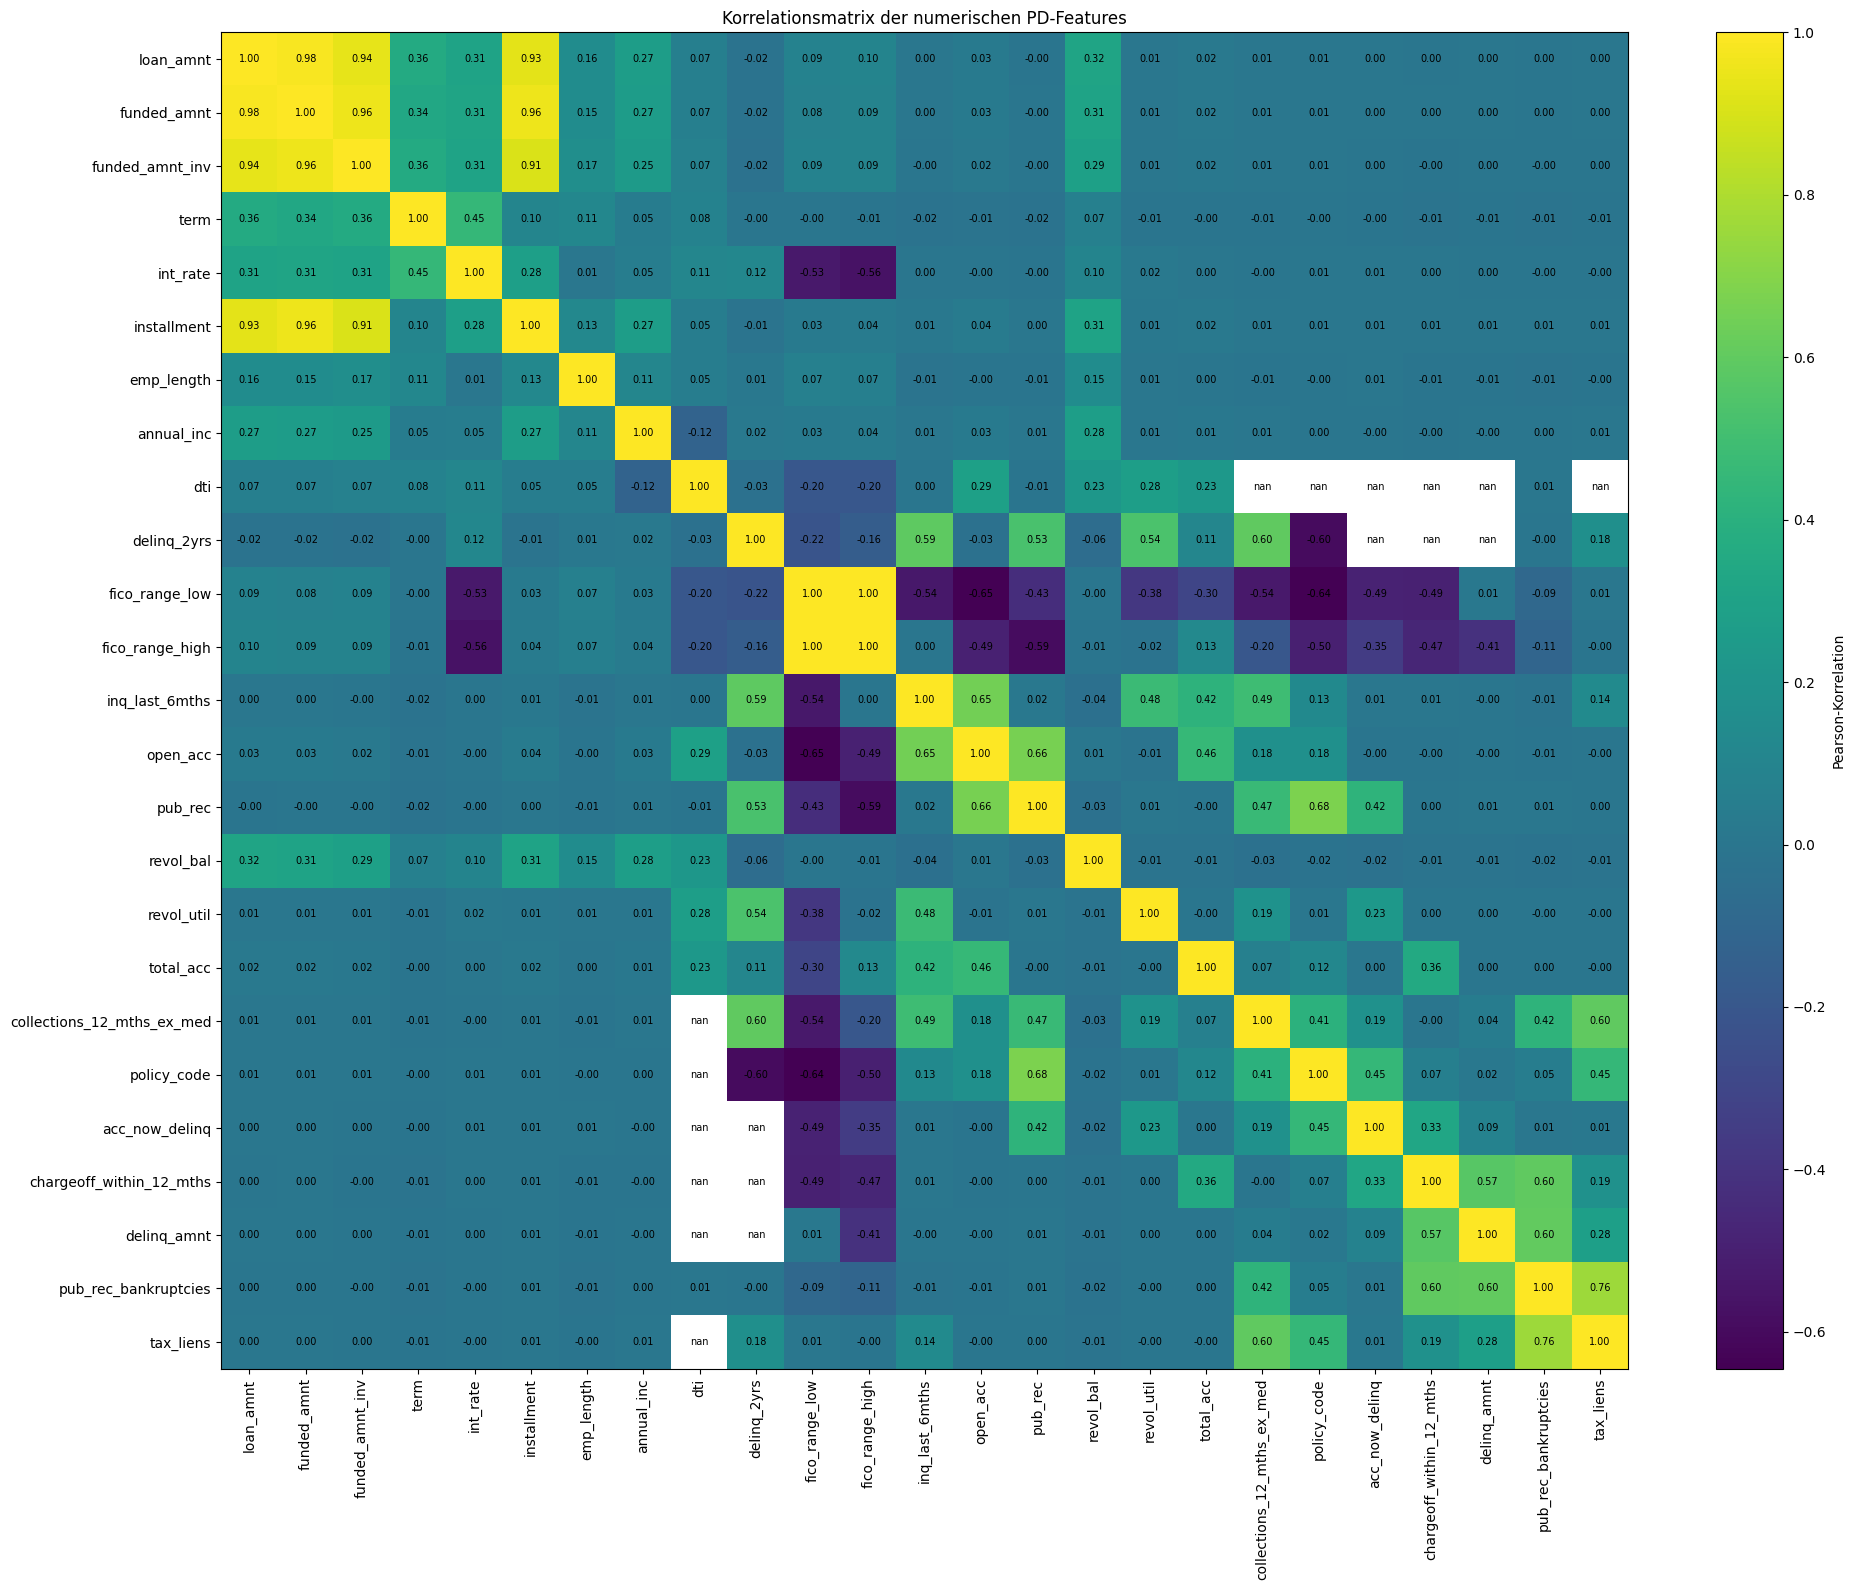

In [0]:
from pyspark.sql.functions import col
import pandas as pd
import matplotlib.pyplot as plt

pd_numeric_features = [
    "loan_amnt",
    "funded_amnt",
    "funded_amnt_inv",
    "term",
    "int_rate",
    "installment",
    "emp_length",
    "annual_inc",
    "dti",
    "delinq_2yrs",
    "fico_range_low",
    "fico_range_high",
    "inq_last_6mths",
    "open_acc",
    "pub_rec",
    "revol_bal",
    "revol_util",
    "total_acc",
    "collections_12_mths_ex_med",
    "policy_code",
    "acc_now_delinq",
    "chargeoff_within_12_mths",
    "delinq_amnt",
    "pub_rec_bankruptcies",
    "tax_liens"
]



# Numerische Features auswählen
df_corr = df_model.select(pd_numeric_features)

# Korrelationsmatrix berechnen
corr_matrix = df_corr.toPandas().corr()

# Heatmap
plt.figure(figsize=(20, 16))

plt.imshow(corr_matrix, aspect="auto")

plt.colorbar(label="Pearson-Korrelation")

# Achsenbeschriftungen
plt.xticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns
)

# Korrelationswerte in die Zellen schreiben
for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        value = corr_matrix.iloc[i, j]
        plt.text(
            j,
            i,
            f"{value:.2f}",
            ha="center",
            va="center",
            fontsize=7
        )

plt.title("Korrelationsmatrix der numerischen PD-Features")

plt.tight_layout()
plt.show()

### 5.2 Korrelation zwischen den Features

Im nächsten Schritt wird die Pearson-Korrelation zwischen den numerischen
Features berechnet.

Die Pearson-Korrelation misst den linearen Zusammenhang zwischen zwei
Variablen und liegt zwischen -1 und +1:

- **+1** → starker positiver linearer Zusammenhang
- **0** → kein linearer Zusammenhang
- **-1** → starker negativer linearer Zusammenhang

Eine hohe Korrelation zwischen zwei Features kann darauf hinweisen, dass
beide Variablen ähnliche Informationen enthalten.

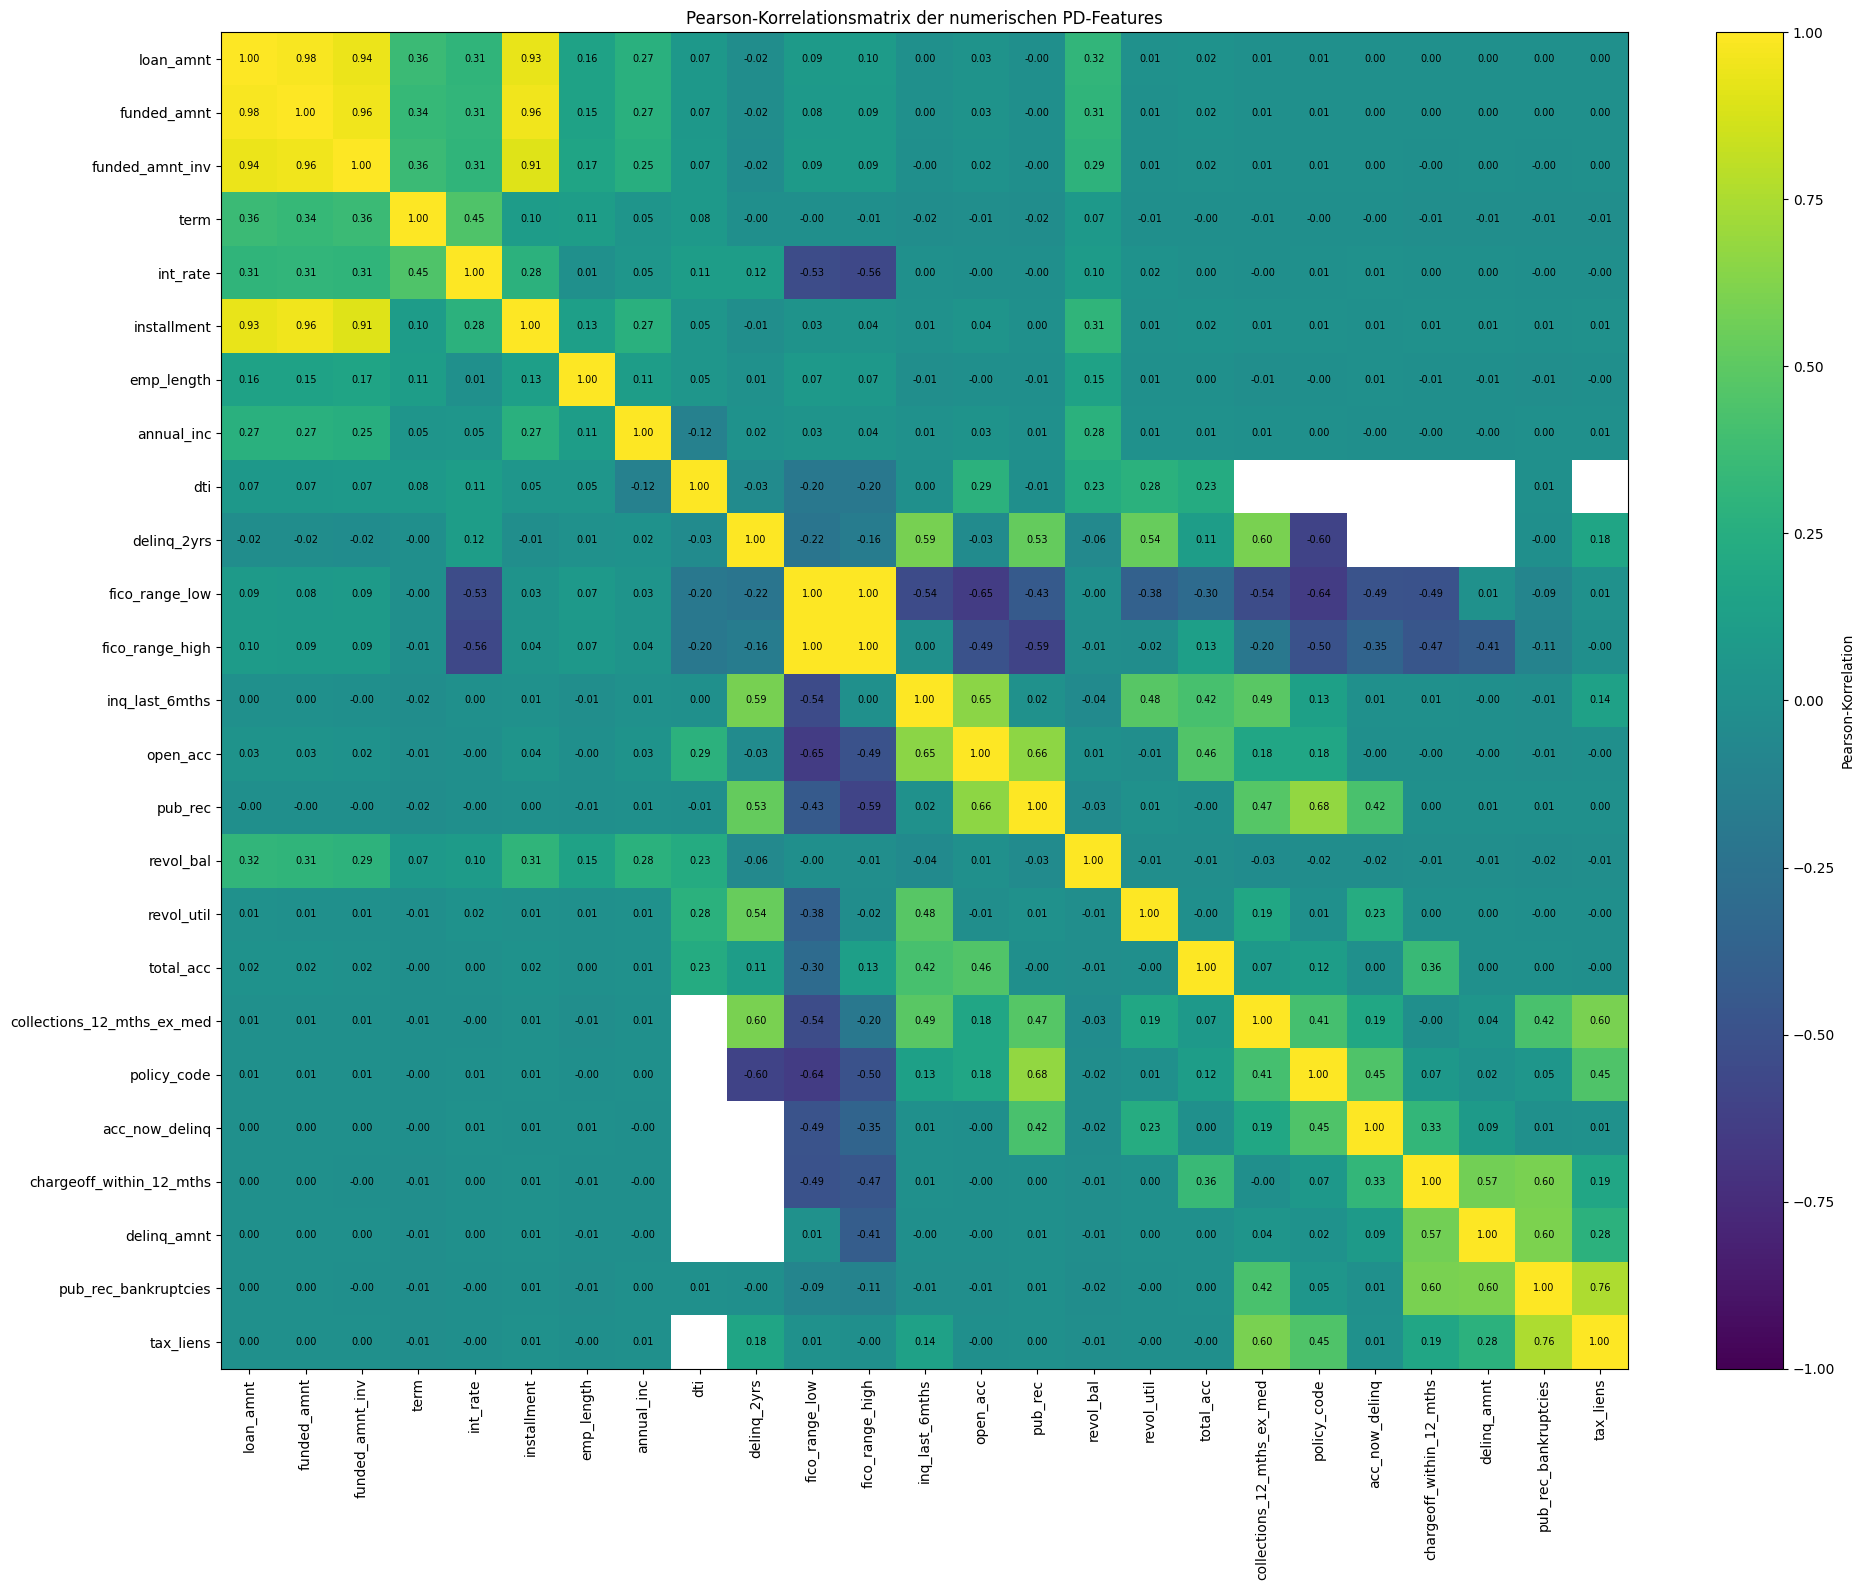

In [0]:
from pyspark.sql.functions import col, corr
import pandas as pd
import matplotlib.pyplot as plt

# Pearson-Korrelation für alle Feature-Paare berechnen
correlations = []

for i, col1 in enumerate(pd_numeric_features):
    for col2 in pd_numeric_features[i+1:]:
        
        correlation = (
            df_corr
            .select(
                corr(col(col1), col(col2)).alias("correlation")
            )
            .collect()[0]["correlation"]
        )

        correlations.append(
            (col1, col2, correlation)
        )

# Spark DataFrame mit den Korrelationen
df_correlations = spark.createDataFrame(
    correlations,
    ["feature_1", "feature_2", "correlation"]
)

# Für die Visualisierung nach Pandas
corr_pd = df_correlations.toPandas()

# Vollständige symmetrische Korrelationsmatrix erstellen
features = pd_numeric_features

corr_full = pd.DataFrame(
    1.0,
    index=features,
    columns=features
)

for _, row in corr_pd.iterrows():
    f1 = row["feature_1"]
    f2 = row["feature_2"]
    value = row["correlation"]

    corr_full.loc[f1, f2] = value
    corr_full.loc[f2, f1] = value

# Heatmap
plt.figure(figsize=(20, 16))

plt.imshow(
    corr_full,
    aspect="auto",
    vmin=-1,
    vmax=1
)

plt.colorbar(label="Pearson-Korrelation")

plt.xticks(
    range(len(features)),
    features,
    rotation=90
)

plt.yticks(
    range(len(features)),
    features
)

# Korrelationswerte anzeigen
for i in range(len(features)):
    for j in range(len(features)):
        value = corr_full.iloc[i, j]

        if pd.notna(value):
            plt.text(
                j,
                i,
                f"{value:.2f}",
                ha="center",
                va="center",
                fontsize=7
            )

plt.title(
    "Pearson-Korrelationsmatrix der numerischen PD-Features"
)

plt.tight_layout()
plt.show()

### 5.3 Identifikation stark korrelierter Features

Abschließend werden Feature-Paare mit einer absoluten Korrelation von
mindestens **0,80** herausgefiltert.

Dieser Schwellenwert dient als Orientierung, um potenziell redundante
Merkmale zu identifizieren.

Eine hohe Korrelation bedeutet jedoch nicht automatisch, dass eines der
Features entfernt werden muss. Die endgültige Entscheidung erfolgt
zusätzlich anhand der fachlichen Bedeutung, der Modellperformance und
möglicher Data-Leakage-Risiken.

In [0]:
from pyspark.sql.functions import abs, col

display(
    df_correlations
    .withColumn(
        "absolute_correlation",
        abs(col("correlation"))
    )
    .filter(
        col("absolute_correlation") >= 0.80
    )
    .orderBy(
        col("absolute_correlation").desc()
    )
)

feature_1,feature_2,correlation,absolute_correlation
fico_range_low,fico_range_high,0.9999441132489743,0.9999441132489743
loan_amnt,funded_amnt,0.9815782188237528,0.9815782188237528
funded_amnt,funded_amnt_inv,0.9584227035378813,0.9584227035378813
funded_amnt,installment,0.956159497355683,0.956159497355683
loan_amnt,funded_amnt_inv,0.9400335103364957,0.9400335103364957
loan_amnt,installment,0.9302876934174854,0.9302876934174854
funded_amnt_inv,installment,0.9050398657030532,0.9050398657030532


Die Korrelationsanalyse zeigt mehrere stark redundante Feature-Paare. 
Insbesondere weisen `fico_range_low` und `fico_range_high` mit einer 
Korrelation von nahezu 1,0 praktisch identische Informationen auf. 
Auch die Variablen `loan_amnt`, `funded_amnt`, `funded_amnt_inv` und 
`installment` sind stark miteinander korreliert. 

Um Redundanzen und mögliche Multikollinearität im späteren PD-Modell zu 
reduzieren, werden diese Variablen im nächsten Schritt fachlich bewertet 
und das Feature-Set entsprechend bereinigt. Dabei wird unter anderem aus 
`fico_range_low` und `fico_range_high` ein gemeinsamer `fico_score`
gebildet.


## 6. Definition der Zielvariable

Für die Modellierung der **Probability of Default (PD)** wird eine binäre
Zielvariable benötigt.

Ein Kredit gilt in diesem Projekt als Default, wenn der historische
Kreditstatus `CHARGED OFF` oder `DEFAULT` entspricht.

Für eine saubere Modellierung werden Kredite mit einem eindeutigen
historischen Ergebnis von Krediten unterschieden, deren Ergebnis zum
Zeitpunkt der Datenerhebung noch nicht feststand, beispielsweise
`CURRENT`.

Daher wird zunächst die Verteilung der Kreditstatus analysiert, bevor die
endgültige Modellierungspopulation definiert wird.

In [0]:
display(
    df_model
    .groupBy("loan_status")
    .count()
    .orderBy(col("count").desc())
)

loan_status,count
FULLY PAID,34075
CHARGED OFF,5642



### 6.1 Definition der PD-Zielvariable

Die Analyse der Kreditstatus zeigt zwei eindeutige historische
Kreditergebnisse:

- `FULLY PAID` → Kredit vollständig zurückgezahlt → **kein Default**
- `CHARGED OFF` → Kredit ausgefallen → **Default**

Damit kann für die PD-Modellierung eine eindeutige binäre Zielvariable
definiert werden.

Die Zielvariable `pd_target` wird wie folgt kodiert:

- `0` = kein Default
- `1` = Default

Da ausschließlich Kredite mit eindeutigem historischem Ergebnis
vorliegen, werden keine offenen oder noch laufenden Kredite in die
Modellierung aufgenommen.


In [0]:
from pyspark.sql.functions import when, col

df_pd = (
    df_model
    .filter(
        col("loan_status").isin(
            "FULLY PAID",
            "CHARGED OFF"
        )
    )
    .withColumn(
        "pd_target",
        when(col("loan_status") == "CHARGED OFF", 1)
        .otherwise(0)
    )
)

display(
    df_pd
    .groupBy("pd_target")
    .count()
    .orderBy("pd_target")
)

pd_target,count
0,34075
1,5642



### 6.2 Verteilung der Zielvariable

Anschließend wird überprüft, wie stark die beiden Klassen im Datensatz
vertreten sind.

Diese Analyse ist wichtig, um eine mögliche **Klassenungleichheit
(Class Imbalance)** zu erkennen. Bei Kreditrisikomodellen ist dies
besonders relevant, da Defaults häufig deutlich seltener auftreten als
nicht ausgefallene Kredite.


In [0]:
from pyspark.sql.functions import count, round, lit

total_pd = df_pd.count()

df_pd_distribution = (
    df_pd
    .groupBy("pd_target")
    .agg(
        count("*").alias("anzahl_kredite")
    )
    .withColumn(
        "anteil_prozent",
        round(
            col("anzahl_kredite") / lit(total_pd) * 100,
            2
        )
    )
    .orderBy("pd_target")
)

display(df_pd_distribution)

pd_target,anzahl_kredite,anteil_prozent
0,34075,85.79
1,5642,14.21



### Ergebnis der Zielvariablenanalyse

Die Zielvariable zeigt eine deutliche, aber noch gut handhabbare
Klassenungleichheit:

- **85,79 %** der Kredite weisen keinen Default auf.
- **14,21 %** der Kredite sind ausgefallen.

Damit liegt ein **imbalanciertes Klassifikationsproblem** vor. Dies wird
bei der späteren Entwicklung und Bewertung des PD-Modells berücksichtigt.

Die Zielvariable `pd_target` ist damit für die weitere Modellierung
geeignet:

- `0` = FULLY PAID
- `1` = CHARGED OFF



## 7. Numerische und kategoriale Features

Nach der Definition der Zielvariable werden die für das PD-Modell
verwendbaren Merkmale in **numerische** und **kategoriale Features**
aufgeteilt.

Zuvor werden die beiden FICO-Grenzwerte zu einem gemeinsamen
`fico_score` zusammengefasst. Dadurch wird die nahezu vollständige
Redundanz zwischen `fico_range_low` und `fico_range_high` reduziert.

In [0]:
from pyspark.sql.functions import col, round

df_pd = df_pd.withColumn(
    "fico_score",
    round(
        (col("fico_range_low") + col("fico_range_high")) / 2,
        0
    )
)

display(
    df_pd.select(
        "fico_range_low",
        "fico_range_high",
        "fico_score"
    ).limit(1)
)

fico_range_low,fico_range_high,fico_score
735.0,739.0,737.0



### 7.2 Numerische Features

Die numerischen Features bilden quantitative Eigenschaften des Kredits
und des Kreditnehmers ab.

Die zuvor als stark redundant identifizierten Variablen
`funded_amnt`, `funded_amnt_inv`, `installment`,
`fico_range_low` und `fico_range_high` werden zunächst nicht verwendet.

Der daraus gebildete `fico_score` bleibt als zusammengefasstes
Bonitätsmerkmal erhalten.


In [0]:
pd_numeric_features = [
    "loan_amnt",
    "term",
    "int_rate",
    "emp_length",
    "annual_inc",
    "dti",
    "delinq_2yrs",
    "fico_score",
    "inq_last_6mths",
    "open_acc",
    "pub_rec",
    "revol_bal",
    "revol_util",
    "total_acc",
    "collections_12_mths_ex_med",
    "acc_now_delinq",
    "delinq_amnt",
    "pub_rec_bankruptcies",
    "tax_liens"
]

df_pd.select(pd_numeric_features).printSchema()

root
 |-- loan_amnt: integer (nullable = true)
 |-- term: integer (nullable = true)
 |-- int_rate: double (nullable = true)
 |-- emp_length: integer (nullable = true)
 |-- annual_inc: integer (nullable = true)
 |-- dti: double (nullable = true)
 |-- delinq_2yrs: double (nullable = true)
 |-- fico_score: double (nullable = true)
 |-- inq_last_6mths: double (nullable = true)
 |-- open_acc: double (nullable = true)
 |-- pub_rec: double (nullable = true)
 |-- revol_bal: double (nullable = true)
 |-- revol_util: double (nullable = true)
 |-- total_acc: double (nullable = true)
 |-- collections_12_mths_ex_med: double (nullable = true)
 |-- acc_now_delinq: double (nullable = true)
 |-- delinq_amnt: double (nullable = true)
 |-- pub_rec_bankruptcies: double (nullable = true)
 |-- tax_liens: double (nullable = true)




### 7.3 Kategoriale Features

Kategoriale Features beschreiben Gruppen oder Klassen und werden später
innerhalb der ML-Pipeline für das Modell in numerische Repräsentationen
überführt.

Für das PD-Modell werden insbesondere Kreditrating, Beschäftigungsdauer,
Wohnsituation, Verifizierungsstatus und Kreditzweck berücksichtigt.


In [0]:
pd_categorical_features = [
    "grade",
    "sub_grade",
    "home_ownership",
    "verification_status",
    "purpose",
    "addr_state",
    "application_type",
    "disbursement_method"
]

df_pd.select(pd_categorical_features).printSchema()

root
 |-- grade: string (nullable = true)
 |-- sub_grade: string (nullable = true)
 |-- home_ownership: string (nullable = true)
 |-- verification_status: string (nullable = true)
 |-- purpose: string (nullable = true)
 |-- addr_state: string (nullable = true)
 |-- application_type: string (nullable = true)
 |-- disbursement_method: string (nullable = true)




## 8. Missing-Value-Analyse

Vor dem Aufbau der Machine-Learning-Pipeline wird die Vollständigkeit
der ausgewählten PD-Features untersucht.

Fehlende Werte werden an dieser Stelle **noch nicht ersetzt**. Sie bleiben
zunächst als `NULL` erhalten, damit die tatsächliche Datenqualität sichtbar
bleibt.

Die spätere Imputation erfolgt innerhalb der ML-Pipeline und wird
ausschließlich auf Basis der Trainingsdaten gelernt. Dadurch wird
verhindert, dass Informationen aus dem Testdatensatz in das Training
einfließen.

In [0]:
from pyspark.sql.functions import col

pd_features = pd_numeric_features + pd_categorical_features

total_rows = df_pd.count()

missing_values = []

for feature in pd_features:

    missing_count = (
        df_pd
        .filter(col(feature).isNull())
        .count()
    )

    # Keine round()-Funktion verwenden
    missing_percent = (missing_count / total_rows) * 100

    missing_values.append(
        (
            feature,
            missing_count,
            missing_percent
        )
    )

df_missing = spark.createDataFrame(
    missing_values,
    ["feature", "missing_count", "missing_percent"]
)

display(
    df_missing
    .orderBy(col("missing_percent").desc())
)

feature,missing_count,missing_percent
emp_length,1075,2.7066495455346575
pub_rec_bankruptcies,725,1.8254148097791876
dti,225,0.5665080444142306
fico_score,192,0.4834201979001435
delinq_2yrs,176,0.44313518140846486
collections_12_mths_ex_med,103,0.25933479366518114
inq_last_6mths,101,0.2542991666037213
revol_util,87,0.21904977717350252
open_acc,79,0.1989072689276632
acc_now_delinq,71,0.1787647606818239


%md

### 8.2 Features mit fehlenden Werten

Für die weitere Analyse werden nur Merkmale angezeigt, bei denen
tatsächlich fehlende Werte vorhanden sind.

Dadurch lässt sich erkennen, bei welchen Variablen eine Imputation
erforderlich ist und wie umfangreich diese ausfällt.

In [0]:
display(
    df_missing
    .filter(col("missing_count") > 0)
    .orderBy(col("missing_percent").desc())
)

feature,missing_count,missing_percent
emp_length,1075,2.7066495455346575
pub_rec_bankruptcies,725,1.8254148097791876
dti,225,0.5665080444142306
fico_score,192,0.4834201979001435
delinq_2yrs,176,0.44313518140846486
collections_12_mths_ex_med,103,0.25933479366518114
inq_last_6mths,101,0.2542991666037213
revol_util,87,0.21904977717350252
open_acc,79,0.1989072689276632
acc_now_delinq,71,0.1787647606818239



### 8.3 Bewertung der Missing Values

Die Verteilung der fehlenden Werte wird nun hinsichtlich ihrer
Auswirkungen auf die spätere Modellierung bewertet.

Features mit einem sehr hohen Anteil fehlender Werte können für ein
Machine-Learning-Modell problematisch sein. Bei einem moderaten Anteil
fehlender Werte ist dagegen eine Imputation innerhalb der ML-Pipeline
sinnvoll.

Für dieses Projekt werden fehlende Werte daher grundsätzlich nicht
bereits im Gold Layer ersetzt. Die Behandlung erfolgt später innerhalb
der Modellierungs-Pipeline.

Als Orientierung wird ein sehr hoher Missing-Anteil von mehr als 50 %
gesondert betrachtet.

#### Features mit mehr als 50 % Missing Values

In [0]:
display(
    df_missing
    .filter(col("missing_percent") > 50)
    .orderBy(col("missing_percent").desc())
)

feature,missing_count,missing_percent


#### Features mit Missing Values unter 50 %

In [0]:
display(
    df_missing
    .filter(
        (col("missing_count") > 0) &
        (col("missing_percent") <= 50)
    )
    .orderBy(col("missing_percent").desc())
)

feature,missing_count,missing_percent
emp_length,1075,2.7066495455346575
pub_rec_bankruptcies,725,1.8254148097791876
dti,225,0.5665080444142306
fico_score,192,0.4834201979001435
delinq_2yrs,176,0.44313518140846486
collections_12_mths_ex_med,103,0.25933479366518114
inq_last_6mths,101,0.2542991666037213
revol_util,87,0.21904977717350252
open_acc,79,0.1989072689276632
acc_now_delinq,71,0.1787647606818239



### Ergebnis der Missing-Value-Analyse

Die Features werden trotz vorhandener fehlender Werte **nicht automatisch
entfernt**. Ein moderater Anteil fehlender Werte stellt keinen
ausreichenden Grund dar, ein fachlich relevantes Merkmal aus dem
PD-Modell auszuschließen.

Die fehlenden Werte werden daher zunächst beibehalten und später innerhalb
der Machine-Learning-Pipeline durch eine geeignete Imputationsstrategie
behandelt.

Dadurch bleibt möglichst viel der vorhandenen Information für die
Modellierung erhalten.


## 9. Feature Engineering

Im nächsten Schritt werden aus den vorhandenen Rohmerkmalen zusätzliche
Features abgeleitet, die für die PD-Modellierung einen höheren
Informationsgehalt besitzen können.

Dabei werden ausschließlich Informationen verwendet, die zum Zeitpunkt der
Kreditvergabe verfügbar sind.

Ziel ist es, die finanzielle Situation und die bisherige Krediterfahrung
des Kreditnehmers möglichst aussagekräftig für das spätere PD-Modell
abzubilden.



### 9.2 Länge der Kredithistorie

Die bisherige Länge der Kredithistorie kann ein relevantes Merkmal für
die Bonitätsbewertung sein.

Sie wird aus dem Zeitraum zwischen dem Beginn der ersten bekannten
Kreditlinie (`earliest_cr_line`) und dem Kreditvergabedatum (`issue_d`)
berechnet und in Monaten angegeben.

In [0]:
from pyspark.sql.functions import months_between, round, col

df_pd = df_pd.withColumn(
    "credit_history_months",
    round(
        months_between(
            col("issue_d"),
            col("earliest_cr_line")
        ),
        0
    )
)

display(
    df_pd.select(
        "issue_d",
        "earliest_cr_line",
        "credit_history_months"
    ).limit(10)
)

issue_d,earliest_cr_line,credit_history_months
2011-12-01,1985-01-01,323.0
2011-12-01,1999-04-01,152.0
2011-12-01,2001-11-01,121.0
2011-12-01,1996-02-01,190.0
2011-12-01,1996-01-01,191.0
2011-12-01,2004-11-01,85.0
2011-12-01,2005-07-01,77.0
2011-12-01,2007-01-01,59.0
2011-12-01,2004-04-01,92.0
2011-12-01,2004-09-01,87.0



### 9.3 Monatliches Einkommen

Das Merkmal `annual_inc` enthält das jährliche Einkommen des Kreditnehmers.

Zusätzlich wird daraus das geschätzte monatliche Einkommen abgeleitet.
Dieses Merkmal kann später gemeinsam mit der monatlichen Kreditrate und
dem DTI für die Analyse der finanziellen Belastung verwendet werden.

Das ursprüngliche `annual_inc` bleibt dabei erhalten.


In [0]:
from pyspark.sql.functions import col

df_pd = df_pd.withColumn(
    "monthly_income",
    col("annual_inc") / 12
)

display(
    df_pd.select(
        "annual_inc",
        "monthly_income"
    ).limit(10)
)

annual_inc,monthly_income
24000,2000.0
30000,2500.0
12252,1021.0
49200,4100.0
80000,6666.666666666667
36000,3000.0
47004,3917.0
48000,4000.0
40000,3333.3333333333335
15000,1250.0



### 9.4 Loan-to-Income Ratio

Das Verhältnis zwischen Kreditbetrag und Jahreseinkommen beschreibt die
relative Größe des beantragten Kredits im Verhältnis zur finanziellen
Leistungsfähigkeit des Kreditnehmers.

Dazu wird der Kreditbetrag `loan_amnt` durch das jährliche Einkommen
`annual_inc` geteilt.

Ein höherer Wert kann auf eine höhere finanzielle Belastung und damit
potenziell auf ein höheres Ausfallrisiko hinweisen.

Das ursprüngliche `loan_amnt` und `annual_inc` bleiben weiterhin erhalten.

In [0]:
from pyspark.sql.functions import col, when

df_pd = df_pd.withColumn(
    "loan_to_income",
    when(
        col("annual_inc") > 0,
        col("loan_amnt") / col("annual_inc")
    )
)

display(
    df_pd.select(
        "loan_amnt",
        "annual_inc",
        "loan_to_income"
    ).limit(10)
)

loan_amnt,annual_inc,loan_to_income
5000,24000,0.20833333333333334
2500,30000,0.08333333333333333
2400,12252,0.1958863858961802
10000,49200,0.2032520325203252
3000,80000,0.0375
5000,36000,0.1388888888888889
7000,47004,0.14892349587269169
3000,48000,0.0625
5600,40000,0.14
5375,15000,0.35833333333333334


##### Aktualisierte Feature-Listen

In [0]:
# Numerische Features für das PD-Modell

pd_numeric_features = [
    "loan_amnt",
    "term",
    "int_rate",
    "emp_length",
    "annual_inc",
    "dti",
    "delinq_2yrs",
    "fico_score",
    "inq_last_6mths",
    "open_acc",
    "pub_rec",
    "revol_bal",
    "revol_util",
    "total_acc",
    "collections_12_mths_ex_med",
    "acc_now_delinq",
    "delinq_amnt",
    "pub_rec_bankruptcies",
    "tax_liens",
    "credit_history_months",
    "loan_to_income"
]

# Kategorische Features für das PD-Modell

pd_categorical_features = [
    "sub_grade",
    "home_ownership",
    "verification_status",
    "purpose",
    "addr_state",
    "application_type",
    "disbursement_method"
]

##### Kurzer Check

In [0]:
print("Numerische Features:", len(pd_numeric_features))
print("Kategorische Features:", len(pd_categorical_features))
print("Gesamte Modell-Features:", len(pd_numeric_features) + len(pd_categorical_features))

Numerische Features: 21
Kategorische Features: 7
Gesamte Modell-Features: 28


## 10 Feature-Qualitätsprüfung

In [0]:
from pyspark.sql.functions import col, countDistinct

feature_cardinality = []

for feature in pd_numeric_features + pd_categorical_features:
    distinct_count = (
        df_pd
        .select(countDistinct(col(feature)).alias("distinct_count"))
        .collect()[0]["distinct_count"]
    )

    feature_cardinality.append(
        (feature, distinct_count)
    )

df_cardinality = spark.createDataFrame(
    feature_cardinality,
    ["feature", "distinct_count"]
)

display(
    df_cardinality
    .orderBy(col("distinct_count").asc())
)

feature,distinct_count
term,2
verification_status,3
home_ownership,5
emp_length,11
disbursement_method,25
sub_grade,35
delinq_amnt,38
pub_rec_bankruptcies,38
tax_liens,42
fico_score,47


## 10.2 Konstante Features identifizieren

In [0]:
display(
    df_cardinality
    .filter(col("distinct_count") <= 1)
)

feature,distinct_count


### 10.3 Kategorische Features prüfen

In [0]:
for feature in pd_categorical_features:
    print(f"\n--- {feature} ---")
    
    display(
        df_pd
        .groupBy(feature)
        .count()
        .orderBy(col("count").desc())
    )


### Ergebnis der Feature-Qualitätsprüfung

Vor dem Aufbau des PD-Modells werden die ausgewählten Features auf ihre
Informationsqualität überprüft.

Dabei werden insbesondere konstante Variablen, die Anzahl unterschiedlicher
Ausprägungen sowie seltene Kategorien untersucht.

Features ohne ausreichende Varianz liefern keinen zusätzlichen
Informationsgehalt für das Modell und werden entfernt.

Bei kategorialen Merkmalen wird zusätzlich geprüft, ob einzelne Kategorien
nur sehr selten vorkommen. Dies ist insbesondere für das spätere
One-Hot-Encoding relevant.

Auf Basis dieser Prüfung wird das finale Feature-Set für die
Machine-Learning-Pipeline festgelegt.

#####10.4 Ausreißeranalyse

In [0]:
from pyspark.sql.functions import (
    col,
    min,
    max,
    percentile_approx
)

outlier_stats = []

for feature in pd_numeric_features:
    stats = (
        df_pd
        .select(
            min(col(feature)).alias("min_value"),
            percentile_approx(col(feature), 0.01).alias("p01"),
            percentile_approx(col(feature), 0.25).alias("q1"),
            percentile_approx(col(feature), 0.50).alias("median"),
            percentile_approx(col(feature), 0.75).alias("q3"),
            percentile_approx(col(feature), 0.99).alias("p99"),
            max(col(feature)).alias("max_value")
        )
        .collect()[0]
    )

    outlier_stats.append(
        (
            feature,
            float(stats["min_value"]) if stats["min_value"] is not None else None,
            float(stats["p01"]) if stats["p01"] is not None else None,
            float(stats["q1"]) if stats["q1"] is not None else None,
            float(stats["median"]) if stats["median"] is not None else None,
            float(stats["q3"]) if stats["q3"] is not None else None,
            float(stats["p99"]) if stats["p99"] is not None else None,
            float(stats["max_value"]) if stats["max_value"] is not None else None
        )
    )

df_outlier_stats = spark.createDataFrame(
    outlier_stats,
    [
        "feature",
        "min_value",
        "p01",
        "q1",
        "median",
        "q3",
        "p99",
        "max_value"
    ]
)

display(df_outlier_stats)

feature,min_value,p01,q1,median,q3,p99,max_value
loan_amnt,500.0,1200.0,5500.0,10000.0,15000.0,35000.0,35000.0
term,36.0,36.0,36.0,36.0,60.0,60.0,60.0
int_rate,5.42,5.42,9.25,11.86,14.59,20.99,24.59
emp_length,0.0,0.0,2.0,4.0,9.0,10.0,10.0
annual_inc,4000.0,14400.0,40320.0,59000.0,82284.0,234000.0,6000000.0
dti,0.0,0.36,8.19,13.41,18.6,26.68,29.99
delinq_2yrs,0.0,0.0,0.0,0.0,0.0,2.0,24.63
fico_score,0.0,662.0,687.0,712.0,742.0,802.0,827.0
inq_last_6mths,0.0,0.0,0.0,1.0,1.0,4.0,809.0
open_acc,0.0,2.0,6.0,9.0,12.0,23.0,799.0



### Ergebnis der Ausreißer- und Datenqualitätsanalyse

Die Analyse der numerischen Features zeigt, dass der Großteil der
Variablen innerhalb plausibler Wertebereiche liegt. Gleichzeitig wurden
bei einzelnen Bonitäts- und Kreditmerkmalen extreme Werte festgestellt.

Besonders auffällig sind beispielsweise sehr hohe Werte bei
`inq_last_6mths`, `open_acc`, `total_acc` und `revol_util`. Diese Werte
erscheinen im Vergleich zur übrigen Datenverteilung fachlich nicht
plausibel und werden daher als potenzielle Datenqualitätsprobleme
behandelt.

Auch beim `fico_score` treten einzelne Werte außerhalb des üblichen
FICO-Bereichs auf. Solche Werte werden nicht als reguläre Beobachtungen
für das PD-Modell verwendet.

Statt die betroffenen Kreditdatensätze vollständig zu entfernen, werden
nur die offensichtlich unplausiblen Einzelwerte auf `NULL` gesetzt.
Dadurch bleibt die Anzahl der Beobachtungen erhalten und gleichzeitig
wird verhindert, dass fehlerhafte Werte die Modellierung beeinflussen.

Die anschließend entstehenden fehlenden Werte werden in der späteren
Machine-Learning-Pipeline durch eine geeignete Imputationsstrategie
behandelt.

Damit ist die Datenqualität der ausgewählten PD-Features ausreichend
vorbereitet, um im nächsten Schritt den **Train-Test-Split und die
Machine-Learning-Pipeline** aufzubauen.

### 10.7 Datenqualitätsregeln definieren

Wir sollten deshalb fachlich plausible Grenzen setzen und Werte außerhalb dieser Grenzen auf NULL setzen.

In [0]:
from pyspark.sql.functions import col, when

df_pd = (
    df_pd
    # FICO
    .withColumn(
        "fico_score",
        when(
            col("fico_score").between(300, 900),
            col("fico_score")
        )
    )

    # Delinquencies
    .withColumn(
        "delinq_2yrs",
        when(
            col("delinq_2yrs").between(0, 50),
            col("delinq_2yrs")
        )
    )

    # Credit inquiries
    .withColumn(
        "inq_last_6mths",
        when(
            col("inq_last_6mths").between(0, 50),
            col("inq_last_6mths")
        )
    )

    # Open accounts
    .withColumn(
        "open_acc",
        when(
            col("open_acc").between(0, 100),
            col("open_acc")
        )
    )

    # Public records
    .withColumn(
        "pub_rec",
        when(
            col("pub_rec").between(0, 50),
            col("pub_rec")
        )
    )

    # Revolving utilization
    .withColumn(
        "revol_util",
        when(
            col("revol_util").between(0, 100),
            col("revol_util")
        )
    )

    # Total accounts
    .withColumn(
        "total_acc",
        when(
            col("total_acc").between(0, 200),
            col("total_acc")
        )
    )

    # Collections
    .withColumn(
        "collections_12_mths_ex_med",
        when(
            col("collections_12_mths_ex_med").between(0, 50),
            col("collections_12_mths_ex_med")
        )
    )

    # Current delinquency
    .withColumn(
        "acc_now_delinq",
        when(
            col("acc_now_delinq").between(0, 50),
            col("acc_now_delinq")
        )
    )

    # Delinquent amount
    .withColumn(
        "delinq_amnt",
        when(
            col("delinq_amnt").between(0, 100000),
            col("delinq_amnt")
        )
    )

    # Public bankruptcies
    .withColumn(
        "pub_rec_bankruptcies",
        when(
            col("pub_rec_bankruptcies").between(0, 20),
            col("pub_rec_bankruptcies")
        )
    )

    # Tax liens
    .withColumn(
        "tax_liens",
        when(
            col("tax_liens").between(0, 50),
            col("tax_liens")
        )
    )
)

#### Kurzer Check

In [0]:
display(
    df_pd.select(pd_numeric_features)
    .summary()
)

summary,loan_amnt,term,int_rate,emp_length,annual_inc,dti,delinq_2yrs,fico_score,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,total_acc,collections_12_mths_ex_med,acc_now_delinq,delinq_amnt,pub_rec_bankruptcies,tax_liens,credit_history_months,loan_to_income
count,39717,39717,39717,38642,39717,39492,39541,39492,39526,39564,39599,39670,39562,39626,39476,39598,39665,38956,39618,39492,39717
mean,11219.443814991062,42.41800740237178,12.02117657426169,4.973448579266083,68968.91980763905,13.323202927175167,0.16124301358084014,716.9874658158615,0.8723065830086524,9.281176321908806,0.07088386070355311,13320.047158810183,48.71110990344263,22.087410790894868,0.005557535425340612,0.0035918480756403103,3.827889624485552,0.04378940342951022,0.001946337523347973,165.50724197305783,0.18791385374682576
stddev,7456.6706941009625,10.622815062240146,3.7248254351142074,3.5625803767162765,63793.76644504277,6.675810197334242,0.6972471269510921,35.84966344523662,1.089504631371204,4.41252132280216,0.49340129943774186,15863.159559368461,28.38857433156259,11.501012677230676,0.3958079568420143,0.2837449583043531,204.16242713918618,0.2179896130481637,0.20872396112626646,82.2055954189173,0.11637015127265057
min,500,36,5.42,0,4000,0.0,0.0,627.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,36.0,7.894736842105263E-4
25%,5500,36,9.25,2,40320,8.19,0.0,687.0,0.0,6.0,0.0,3639.0,25.2,13.0,0.0,0.0,0.0,0.0,0.0,110.0,0.1
50%,10000,36,11.86,4,59000,13.41,0.0,712.0,1.0,9.0,0.0,8808.0,49.2,20.0,0.0,0.0,0.0,0.0,0.0,151.0,0.1661019201381968
75%,15000,60,14.59,9,82284,18.6,0.0,742.0,1.0,12.0,0.0,16995.0,72.3,29.0,0.0,0.0,0.0,0.0,0.0,205.0,0.25125628140703515
max,35000,60,24.59,10,6000000,29.99,24.63,827.0,22.97,44.0,23.0,149588.0,99.9,94.8,45.000000002761,45.000000099205,18610.0,14.86,34.0,785.0,0.83




### Ergebnis der Ausreißer- und Datenqualitätsanalyse

Die Analyse der Wertebereiche zeigt, dass einzelne Variablen extreme und
fachlich nicht plausible Werte enthalten.

Insbesondere bei Kreditkarten- und Bonitätsmerkmalen treten teilweise
Werte auf, die deutlich außerhalb realistischer Wertebereiche liegen.
Diese Werte werden nicht als normale statistische Ausreißer interpretiert,
sondern als potenzielle Datenqualitätsprobleme behandelt.

Daher werden für ausgewählte Features fachlich plausible Wertebereiche
definiert. Werte außerhalb dieser Bereiche werden auf `NULL` gesetzt.

Die betroffenen Kreditdatensätze werden nicht entfernt. Die entstandenen
fehlenden Werte werden später innerhalb der Machine-Learning-Pipeline
behandelt.

Dadurch bleibt die Anzahl der Beobachtungen erhalten, während offensichtlich
fehlerhafte Einzelwerte nicht direkt in das PD-Modell eingehen.

## 11. Train-Test-Split

#### Modell-Datensatz definieren

In [0]:
from pyspark.sql.functions import col

df_pd_model = (
    df_pd
    .filter(col("pd_target").isNotNull())
)

In [0]:
# 80 % Training / 20 % Test

df_train, df_test = df_pd_model.randomSplit(
    [0.8, 0.2],
    seed=42
)

total_count = df_pd_model.count()
train_count = df_train.count()
test_count = df_test.count()

print("Gesamt:", total_count)
print("Training:", train_count)
print("Test:", test_count)

print(
    "Training-Anteil:",
    f"{train_count / total_count * 100:.2f} %"
)

print(
    "Test-Anteil:",
    f"{test_count / total_count * 100:.2f} %"
)

Gesamt: 39717
Training: 31703
Test: 8014
Training-Anteil: 79.82 %
Test-Anteil: 20.18 %



### Ergebnis des Train-Test-Splits

Der Datensatz umfasst insgesamt **39.717 Kredite**.

Die Daten wurden mit einem Verhältnis von ungefähr **80 % Training und
20 % Test** zufällig aufgeteilt:

- **Training:** 31.703 Kredite (**79,82 %**)
- **Test:** 8.014 Kredite (**20,18 %**)

Die geringfügige Abweichung vom exakten Verhältnis 80/20 entsteht durch
die zufällige Aufteilung der einzelnen Beobachtungen.

Der Trainingsdatensatz wird für die Entwicklung des PD-Modells verwendet.
Der Testdatensatz bleibt während des Trainings vollständig unberührt und
dient anschließend zur Bewertung der Modellgüte.

Durch den festen `seed=42` ist die Aufteilung reproduzierbar.

Damit stehen ausreichend Beobachtungen für das Training sowie eine
ausreichend große unabhängige Testmenge für die spätere Modellbewertung
zur Verfügung.



## Aufbau der Pipeline – Numerische Features

Für die numerischen Merkmale wird eine mehrstufige Transformation
innerhalb der Machine-Learning-Pipeline durchgeführt.

### a. Imputation

Fehlende Werte werden mithilfe des **Medians** des jeweiligen Features
ersetzt.

Der Median ist gegenüber extremen Werten robuster als der Mittelwert und
eignet sich daher besonders für Kreditdaten, bei denen einzelne
Ausreißer auftreten können.

Die imputierten Variablen werden mit dem Suffix `_imputed` gespeichert.

### b. VectorAssembler

Anschließend werden alle imputierten numerischen Features zu einem
gemeinsamen Feature-Vektor zusammengeführt.

Dies ist notwendig, da Spark ML-Modelle die Eingangsvariablen
typischerweise als einen gemeinsamen Vektor erwarten.

### c. StandardScaler

Der Feature-Vektor wird anschließend standardisiert.

Mit `withStd=True` werden die numerischen Features auf eine vergleichbare
Skalierung gebracht, indem sie anhand ihrer Standardabweichung skaliert
werden.

`withMean=False` verhindert dabei eine Zentrierung auf den Mittelwert.
Dies ermöglicht eine effiziente Verarbeitung des Feature-Vektors und
vermeidet insbesondere bei später hinzukommenden Sparse Features eine
unnötige Verdichtung.

### Ergebnis

Die Pipeline erzeugt aus den ursprünglichen numerischen Variablen einen
bereinigten und skalierten Feature-Vektor:

Originalwerte
→ Missing-Value-Imputation
→ Zusammenführung zu einem Vektor
→ Standardisierung
→ `numeric_features_scaled`

Dieser skalierte Vektor kann anschließend mit den aufbereiteten
kategorischen Features zu einem gemeinsamen Modell-Feature-Vektor
kombiniert werden.

In [0]:
from pyspark.ml.feature import Imputer, VectorAssembler, StandardScaler

# -----------------------------
# Numerische Features:
# Fehlende Werte mit Median auffüllen
# -----------------------------

imputer = Imputer(
    inputCols=pd_numeric_features,
    outputCols=[f"{c}_imputed" for c in pd_numeric_features]
).setStrategy("median")


# -----------------------------
# Numerische Features zu einem Vektor zusammenfassen
# -----------------------------

assembler_numeric = VectorAssembler(
    inputCols=[f"{c}_imputed" for c in pd_numeric_features],
    outputCol="numeric_features_vector"
)


# -----------------------------
# Standardisierung
# -----------------------------

scaler = StandardScaler(
    inputCol="numeric_features_vector",
    outputCol="numeric_features_scaled",
    withMean=False,
    withStd=True
)

## 12.1 Imports und Pipeline-Komponenten

In [0]:
from pyspark.ml import Pipeline
from pyspark.ml.feature import (
    Imputer,
    StringIndexer,
    OneHotEncoder,
    VectorAssembler
)
from pyspark.ml.classification import LogisticRegression

## 12.2 Numerische Missing Values imputieren

Für numerische Features verwenden wir zunächst den Median.


In [0]:
imputer = Imputer(
    inputCols=pd_numeric_features,
    outputCols=pd_numeric_features,
    strategy="median"
)

## 12.3 Kategorische Features encoden
Wir  können  zunächst die vorbereiteten Features zusammenführen:

In [0]:
indexers = [
    StringIndexer(
        inputCol=feature,
        outputCol=f"{feature}_indexed",
        handleInvalid="keep"
    )
    for feature in pd_categorical_features
]

encoder = OneHotEncoder(
    inputCols=[
        f"{feature}_indexed"
        for feature in pd_categorical_features
    ],
    outputCols=[
        f"{feature}_encoded"
        for feature in pd_categorical_features
    ]
)

### 12.4 Features zusammenführen

In [0]:
assembler = VectorAssembler(
    inputCols=(
        pd_numeric_features +
        [
            f"{feature}_encoded"
            for feature in pd_categorical_features
        ]
    ),
    outputCol="features",
    handleInvalid="keep"
)

##### Klassenverteilung und Class Weighting

In [0]:
from pyspark.sql.functions import col, when, lit
from pyspark.ml.classification import LogisticRegression

# ============================================================
# 1. Klassenverteilung
# ============================================================

class_distribution = (
    df_train
    .groupBy("pd_target")
    .count()
    .orderBy("pd_target")
)

display(class_distribution)


# ============================================================
# 2. Klassenanzahl
# ============================================================

class_counts = {
    row["pd_target"]: row["count"]
    for row in class_distribution.collect()
}

count_0 = class_counts[0]
count_1 = class_counts[1]

total = count_0 + count_1
num_classes = 2


# ============================================================
# 3. Class Weights
# ============================================================

weight_0 = total / (num_classes * count_0)
weight_1 = total / (num_classes * count_1)

print(f"Weight Klasse 0: {weight_0:.4f}")
print(f"Weight Klasse 1: {weight_1:.4f}")


# ============================================================
# 4. Weight Column erzeugen
# ============================================================

df_train_weighted = (
    df_train
    .withColumn(
        "class_weight",
        when(col("pd_target") == 1, lit(weight_1))
        .otherwise(lit(weight_0))
    )
)

display(
    df_train_weighted
    .groupBy("pd_target", "class_weight")
    .count()
    .orderBy("pd_target")
)


pd_target,count
0,27162
1,4541


Weight Klasse 0: 0.5836
Weight Klasse 1: 3.4908


pd_target,class_weight,count
0,0.5835910463147044,27162
1,3.4907509359171986,4541



### Behandlung der Klassenungleichheit

Die Zielvariable `pd_target` weist eine deutliche Klassenungleichheit auf.
Im Trainingsdatensatz entfallen 27.162 Beobachtungen auf `Kein Default`
und 4.541 Beobachtungen auf `Default`.

Da die Default-Klasse deutlich seltener vorkommt, besteht bei einem
ungewichteten Modell die Gefahr, dass das Modell überwiegend die dominante
Klasse vorhersagt und tatsächliche Kreditausfälle nur unzureichend erkennt.

Um diesem Problem entgegenzuwirken, werden für die beiden Klassen
gewichtete Beobachtungen erzeugt. Die Gewichte werden automatisch anhand
der jeweiligen Klassenhäufigkeit berechnet.

Die seltenere Default-Klasse erhält dadurch ein höheres Gewicht. Fehler
bei der Erkennung von Defaults werden somit beim Training stärker
berücksichtigt.

Das Class Weighting wird ausschließlich auf den Trainingsdatensatz
angewendet. Der Testdatensatz bleibt unverändert und wird später für eine
unverfälschte Bewertung des Modells verwendet.

## 12.5  Vergleich und Auswahl des PD-Modells

In [0]:
from pyspark.ml.classification import (
    LogisticRegression,
    RandomForestClassifier,
    GBTClassifier,
    DecisionTreeClassifier,
    NaiveBayes,
    LinearSVC,
    MultilayerPerceptronClassifier
)

from pyspark.ml import Pipeline
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.sql import functions as F


# ==========================================================
# 1. Feature-Anzahl für Multilayer Perceptron bestimmen
# ==========================================================

preprocessing_pipeline = Pipeline(
    stages=[
        imputer,
        *indexers,
        encoder,
        assembler
    ]
)

preprocessing_model = preprocessing_pipeline.fit(df_train_final)

df_train_features = preprocessing_model.transform(df_train_final)

num_features = len(
    df_train_features
    .select("features")
    .first()["features"]
)

print("Anzahl Input-Features für MLP:", num_features)


# ==========================================================
# 2. Modelle definieren
# ==========================================================

pd_models = {

    # ------------------------------------------------------
    # 1. Logistic Regression
    # ------------------------------------------------------
    "Logistic Regression": LogisticRegression(
        featuresCol="features",
        labelCol="pd_target",
        weightCol="class_weight",
        predictionCol="prediction",
        probabilityCol="probability",
        rawPredictionCol="rawPrediction",
        maxIter=1000,
        regParam=0.01,
        elasticNetParam=1.0
    ),

    # ------------------------------------------------------
    # 2. Random Forest
    # ------------------------------------------------------
    "Random Forest": RandomForestClassifier(
        featuresCol="features",
        labelCol="pd_target",
        weightCol="class_weight",
        predictionCol="prediction",
        probabilityCol="probability",
        rawPredictionCol="rawPrediction",
        numTrees=200,
        maxDepth=8,
        minInstancesPerNode=5,
        seed=42
    ),

    # ------------------------------------------------------
    # 3. GBT Classifier
    # ------------------------------------------------------
    "GBT Classifier": GBTClassifier(
    featuresCol="features",
    labelCol="pd_target",
    predictionCol="prediction",
    maxDepth=5,
    maxIter=100,
    stepSize=0.05,
    seed=42
    ),
    # ------------------------------------------------------
    # 4. Decision Tree
    # ------------------------------------------------------
    "Decision Tree": DecisionTreeClassifier(
        featuresCol="features",
        labelCol="pd_target",
        weightCol="class_weight",
        predictionCol="prediction",
        probabilityCol="probability",
        rawPredictionCol="rawPrediction",
        maxDepth=8,
        minInstancesPerNode=5,
        seed=42
    ),

    # ------------------------------------------------------
    # 5. Naive Bayes
    # ------------------------------------------------------
    "Naive Bayes": NaiveBayes(
        featuresCol="features",
        labelCol="pd_target",
        predictionCol="prediction",
        probabilityCol="probability",
        rawPredictionCol="rawPrediction"
    ),

    # ------------------------------------------------------
    # 6. Linear SVM
    # ------------------------------------------------------
    "Linear SVM": LinearSVC(
        featuresCol="features",
        labelCol="pd_target",
        weightCol="class_weight",
        predictionCol="prediction",
        rawPredictionCol="rawPrediction",
        maxIter=100,
        regParam=0.1
    ),

    # ------------------------------------------------------
    # 7. Multilayer Perceptron
    # ------------------------------------------------------
    "Multilayer Perceptron": MultilayerPerceptronClassifier(
        featuresCol="features",
        labelCol="pd_target",
        predictionCol="prediction",
        probabilityCol="probability",
        rawPredictionCol="rawPrediction",
        layers=[num_features, 32, 16, 2],
        maxIter=100,
        blockSize=128,
        seed=42
    )
}


# ==========================================================
# 3. Evaluator
# ==========================================================

evaluator = BinaryClassificationEvaluator(
    labelCol="pd_target",
    rawPredictionCol="rawPrediction",
    metricName="areaUnderROC"
)


# ==========================================================
# 4. Modelle trainieren und Validation bewerten
# ==========================================================

pd_results = []

for name, model in pd_models.items():

    print("=" * 60)
    print(f"Training: {name}")

    pipeline = Pipeline(
        stages=[
            imputer,
            *indexers,
            encoder,
            assembler,
            model
        ]
    )

    # Modell trainieren
    model_fit = pipeline.fit(df_train_final)

    # Validation
    predictions = model_fit.transform(df_validation)

    # ROC-AUC
    auc = evaluator.evaluate(predictions)

    pd_results.append(
        (name, float(auc))
    )

    print(f"{name}: ROC-AUC = {auc:.4f}")


# ==========================================================
# 5. Ergebnisse als DataFrame
# ==========================================================

pd_results_df = spark.createDataFrame(
    pd_results,
    ["Model", "ROC_AUC"]
)


# ==========================================================
# 6. Nach ROC-AUC sortieren
# ==========================================================

pd_results_df = pd_results_df.orderBy(
    F.desc("ROC_AUC")
)

pd_results_df.show(
    truncate=False
)

Exception ignored in: <function JavaWrapper.__del__ at 0xffb301a44400>
Traceback (most recent call last):
  File "/databricks/python/lib/python3.12/site-packages/pyspark/ml/util.py", line 506, in wrapped
    if isinstance(self._java_obj, RemoteModelRef):
                  ^^^^^^^^^^^^^^
AttributeError: 'GBTClassifier' object has no attribute '_java_obj'


Anzahl Input-Features für MLP: 464
Training: Logistic Regression
Logistic Regression: ROC-AUC = 0.6895
Training: Random Forest
Random Forest: ROC-AUC = 0.6780
Training: GBT Classifier
GBT Classifier: ROC-AUC = 0.6788
Training: Decision Tree
Decision Tree: ROC-AUC = 0.5875
Training: Naive Bayes
Naive Bayes: ROC-AUC = 0.4923
Training: Linear SVM
Linear SVM: ROC-AUC = 0.6792
Training: Multilayer Perceptron
Multilayer Perceptron: ROC-AUC = 0.4970
+---------------------+-------------------+
|Model                |ROC_AUC            |
+---------------------+-------------------+
|Logistic Regression  |0.6895067920117828 |
|Linear SVM           |0.6791699326648685 |
|GBT Classifier       |0.6787723227566226 |
|Random Forest        |0.6779660221719175 |
|Decision Tree        |0.5875303822685347 |
|Multilayer Perceptron|0.49696177314652695|
|Naive Bayes          |0.49231463871304915|
+---------------------+-------------------+



Für die Vorhersage der **Probability of Default (PD)** wurden sieben verschiedene Klassifikationsmodelle getestet:

- Logistic Regression
- Linear SVM
- GBT Classifier
- Random Forest
- Decision Tree
- Multilayer Perceptron
- Naive Bayes

Die Modelle wurden mit denselben Trainings- und Validierungsdaten sowie derselben Vorverarbeitung trainiert. Als zentrale Bewertungsmetrik wurde die **ROC-AUC** verwendet.

Die **Logistic Regression** erzielte mit einer ROC-AUC von **0,6895** das beste Ergebnis. Danach folgten Linear SVM (0,6792), GBT Classifier (0,6788) und Random Forest (0,6780).

Die Modelle Decision Tree (0,5875), Multilayer Perceptron (0,4970) und Naive Bayes (0,4923) zeigten eine deutlich schlechtere Trennschärfe.

Aufgrund der höchsten ROC-AUC sowie der guten Interpretierbarkeit und der direkten Ausgabe von Wahrscheinlichkeiten wurde die **Logistic Regression als finales PD-Modell ausgewählt**.

Das ausgewählte Modell wird im nächsten Schritt auf dem gesamten Trainingsdatensatz trainiert und anschließend auf dem bisher unberührten Testdatensatz final evaluiert.

### Finales PD-Modell
Als finales PD-Modell wurde eine **Logistic Regression** mit L2-Regularisierung (`elasticNetParam = 0.0`) und `regParam = 0.1` gewählt. Zur Berücksichtigung der Klassenungleichheit wird `class_weight` verwendet. Das Modell liefert sowohl die Klassifikation als auch die **Probability of Default (PD)** als vorhergesagte Wahrscheinlichkeit.

In [0]:
lr= LogisticRegression(
        featuresCol="features",
        labelCol="pd_target",
        weightCol="class_weight",
        predictionCol="prediction",
        probabilityCol="probability",
        rawPredictionCol="rawPrediction",
        maxIter=1000,
        regParam=0.1,
        elasticNetParam=0.0
    )


### 12.6 Gesamte Pipeline

In [0]:
pipeline = Pipeline(
    stages=[
        imputer,
        *indexers,
        encoder,
        assembler,
        lr
    ]
)

%md

## 12. Aufbau der PD-Machine-Learning-Pipeline

Für die Modellierung der Probability of Default (PD) wird zunächst eine
Logistic Regression verwendet.

Die Datenvorbereitung wird vollständig innerhalb einer PySpark
Machine-Learning-Pipeline durchgeführt.

Die Pipeline besteht aus folgenden Schritten:

1. **Imputation**
   Fehlende numerische Werte werden anhand des Medians ersetzt.

2. **StringIndexer**
   Kategoriale Merkmale werden in numerische Kategorien überführt.

3. **One-Hot-Encoding**
   Die kategorischen Merkmale werden anschließend in binäre Feature-
   Repräsentationen umgewandelt.

4. **VectorAssembler**
   Alle numerischen und kategorisch encodierten Features werden zu einem
   gemeinsamen Feature-Vektor zusammengeführt.

5. **Logistic Regression**
   Das Modell schätzt die Wahrscheinlichkeit für `pd_target = 1`,
   also die Wahrscheinlichkeit eines Kreditausfalls.

Die Verwendung einer Pipeline stellt sicher, dass die notwendigen
Transformationsschritte während des Trainings aus den Trainingsdaten
gelernt und anschließend konsistent auf den Testdatensatz angewendet
werden.

Damit wird verhindert, dass Informationen aus dem Testdatensatz in die
Datenvorbereitung des Modells einfließen.

## 12.7 Modell trainieren

In [0]:
from sklearn.metrics import confusion_matrix, classification_report

# 1. Pipeline trainieren
pipeline_model = pipeline.fit(df_train_weighted)

# 2. Mit dem trainierten Modell Vorhersagen erzeugen
train_predictions = pipeline_model.transform(df_train_weighted)

# Nur benötigte Spalten nach Pandas
df_train_eval = train_predictions.select(
    "pd_target",
    "prediction"
).toPandas()

# Confusion Matrix
cm = confusion_matrix(
    df_train_eval["pd_target"],
    df_train_eval["prediction"]
)

print("Confusion Matrix:")
print(cm)

# Classification Report
print("\nClassification Report:")
print(
    classification_report(
        df_train_eval["pd_target"],
        df_train_eval["prediction"],
        target_names=["Kein Default", "Default"]
    )
)

Confusion Matrix:
[[17227  9935]
 [ 1513  3028]]

Classification Report:
              precision    recall  f1-score   support

Kein Default       0.92      0.63      0.75     27162
     Default       0.23      0.67      0.35      4541

    accuracy                           0.64     31703
   macro avg       0.58      0.65      0.55     31703
weighted avg       0.82      0.64      0.69     31703



In [0]:
train_predictions.select(
    "features"
).show(5, truncate=False)

+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|features                                                                                                                                                                                 |
+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|(539,[0,1,2,4,5,7,9,11,12,13,19,20,25,56,62,64,246,446,518],[25000.0,36.0,11.89,85000.0,19.48,737.0,10.0,28854.0,52.1,42.0,186.0,0.29411764705882354,1.0,1.0,1.0,1.0,1.0,1.0,1.0])       |
|(539,[0,1,2,4,5,7,9,11,12,13,19,20,24,56,61,65,247,446,518],[7000.0,36.0,10.71,65000.0,14.29,707.0,7.0,33623.0,76.7,7.0,91.0,0.1076923076923077,1.0,1.0,1.0,1.0,1.0,1.0,1.0])            |
|(539,[0,1,2,3,4,5,7,9,11,12,13,19,20,28,58,61,64,249,446,51

## Hyperparameter-Tuning der Logistic Regression

Um die Performance des Logistic-Regression-Modells zu verbessern, werden ausgewählte Hyperparameter mithilfe eines Grid Search / Cross-Validation-Verfahrens systematisch getestet.

### Welche Parameter werden untersucht?

**a). `regParam` – Stärke der Regularisierung**

Getestete Werte:

- `0.001`
- `0.01`
- `0.1`
- `0.5`
- `1.0`

Die Regularisierung verhindert, dass das Modell zu stark auf einzelne Merkmale bzw. auf die Trainingsdaten reagiert.

- Ein kleiner Wert erlaubt dem Modell, die Trainingsdaten stärker zu berücksichtigen.
- Ein großer Wert bestraft große Koeffizienten stärker und kann dadurch Overfitting reduzieren.

Ziel ist es, ein sinnvolles Verhältnis zwischen Modellkomplexität und Generalisierungsfähigkeit zu finden.

---

**b). `elasticNetParam` – Art der Regularisierung**

Getestete Werte:

- `0.0` → reine L2-Regularisierung
- `0.5` → Kombination aus L1- und L2-Regularisierung
- `1.0` → reine L1-Regularisierung

Damit wird untersucht, welche Form der Regularisierung für die PD-Klassifikation am besten geeignet ist.

- **L2-Regularisierung** stabilisiert die Koeffizienten und ist häufig ein guter Ausgangspunkt bei vielen korrelierten Merkmalen.
- **L1-Regularisierung** kann unwichtige Merkmale stärker auf null reduzieren und dadurch eine Art Feature Selection bewirken.
- **Elastic Net** kombiniert beide Ansätze.

---

### Warum wird Grid Search verwendet?

Die optimale Kombination der Hyperparameter ist vorab nicht bekannt. Deshalb werden mehrere Kombinationen systematisch getestet.

Bei

- 5 Werten für `regParam`
- 3 Werten für `elasticNetParam`

werden insgesamt **15 verschiedene Parameterkombinationen** untersucht.

Durch Cross-Validation wird jede Kombination auf mehreren Trainings-/Validierungsaufteilungen getestet. Dadurch wird vermieden, dass die Auswahl des besten Modells nur von einer einzelnen Datenaufteilung abhängt.

Als primäres Optimierungskriterium wird zunächst die **ROC-AUC** verwendet.

### Ziel des Tunings

Ziel ist nicht, die Accuracy zu maximieren. Aufgrund der unausgeglichenen Klassenverteilung wäre die Accuracy für das PD-Modell wenig aussagekräftig.

Stattdessen soll ein Modell gefunden werden, das Defaults möglichst gut von Nicht-Defaults unterscheiden kann.

Das beste Modell wird anschließend auf dem unabhängigen Testdatensatz anhand weiterer Kennzahlen bewertet:

- **ROC-AUC** – Trennfähigkeit des Modells
- **KS** – maximale Trennung zwischen Default- und Nicht-Default-Verteilung
- **Gini** – abgeleitete Kennzahl aus der ROC-AUC
- **Brier Score** – Qualität der vorhergesagten PD-Wahrscheinlichkeiten
- **Calibration** – Vergleich zwischen vorhergesagter und tatsächlich beobachteter Default-Rate

Insbesondere bei einem PD-Modell ist neben der Trennfähigkeit auch die **Kalibrierung der vorhergesagten Wahrscheinlichkeiten** wichtig.

In [0]:
from pyspark.ml.classification import LogisticRegression
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from itertools import product

# ============================================================
# 1. Train / Validation Split
# ============================================================

df_train_final, df_validation = df_train_weighted.randomSplit(
    [0.8, 0.2],
    seed=42
)

print(f"Train: {df_train_final.count()}")
print(f"Validation: {df_validation.count()}")


# ============================================================
# 2. Parameter definieren
# ============================================================

reg_params = [0.001, 0.01, 0.1, 0.5, 1.0]
elastic_net_params = [0.0, 0.5, 1.0]

param_combinations = list(
    product(reg_params, elastic_net_params)
)

print(f"Anzahl getesteter Modelle: {len(param_combinations)}")


# ============================================================
# 3. Evaluator
# ============================================================

evaluator = BinaryClassificationEvaluator(
    labelCol="pd_target",
    rawPredictionCol="rawPrediction",
    metricName="areaUnderROC"
)


# ============================================================
# 4. Grid Search auf Validation
# ============================================================

results = []

for reg_param, elastic_net_param in param_combinations:

    print(
        f"Teste regParam={reg_param}, "
        f"elasticNetParam={elastic_net_param}"
    )

    lr_grid = LogisticRegression(
        featuresCol="features",
        labelCol="pd_target",
        weightCol="class_weight",
        predictionCol="prediction",
        probabilityCol="probability",
        rawPredictionCol="rawPrediction",
        maxIter=1000,
        regParam=reg_param,
        elasticNetParam=elastic_net_param
    )

    pipeline_grid = Pipeline(
        stages=[
            imputer,
            *indexers,
            encoder,
            assembler,
            lr_grid
        ]
    )

    # Training nur auf Trainingsdaten
    model = pipeline_grid.fit(df_train_final)

    # Bewertung nur auf Validation-Daten
    validation_predictions = model.transform(df_validation)

    # ROC-AUC
    auc = evaluator.evaluate(validation_predictions)

    results.append(
        (
            reg_param,
            elastic_net_param,
            auc
        )
    )

    print(f"Validation ROC-AUC: {auc:.4f}")


# ============================================================
# 5. Ergebnisse anzeigen
# ============================================================

results_df = spark.createDataFrame(
    results,
    [
        "regParam",
        "elasticNetParam",
        "ROC_AUC"
    ]
)

display(
    results_df.orderBy(
        "ROC_AUC",
        ascending=False
    )
)

Train: 25294
Validation: 6409
Anzahl getesteter Modelle: 15
Teste regParam=0.001, elasticNetParam=0.0
Validation ROC-AUC: 0.6847
Teste regParam=0.001, elasticNetParam=0.5
Validation ROC-AUC: 0.6832
Teste regParam=0.001, elasticNetParam=1.0
Validation ROC-AUC: 0.6842
Teste regParam=0.01, elasticNetParam=0.0
Validation ROC-AUC: 0.6852
Teste regParam=0.01, elasticNetParam=0.5
Validation ROC-AUC: 0.6891
Teste regParam=0.01, elasticNetParam=1.0
Validation ROC-AUC: 0.6895
Teste regParam=0.1, elasticNetParam=0.0
Validation ROC-AUC: 0.6852
Teste regParam=0.1, elasticNetParam=0.5
Validation ROC-AUC: 0.6623
Teste regParam=0.1, elasticNetParam=1.0
Validation ROC-AUC: 0.6542
Teste regParam=0.5, elasticNetParam=0.0
Validation ROC-AUC: 0.6811
Teste regParam=0.5, elasticNetParam=0.5
Validation ROC-AUC: 0.5000
Teste regParam=0.5, elasticNetParam=1.0
Validation ROC-AUC: 0.5000
Teste regParam=1.0, elasticNetParam=0.0
Validation ROC-AUC: 0.6782
Teste regParam=1.0, elasticNetParam=0.5
Validation ROC-AUC: 

regParam,elasticNetParam,ROC_AUC
0.01,1.0,0.6895067920117828
0.01,0.5,0.6891030926723577
0.01,0.0,0.6851775059207262
0.1,0.0,0.6851595371073976
0.001,0.0,0.6847246918248691
0.001,1.0,0.6842059920801452
0.001,0.5,0.6832332803186798
0.5,0.0,0.6810530643015992
1.0,0.0,0.6782247730838352
0.1,0.5,0.6622787490032294


### Ergebnis des Grid Search

Die beste Modellkonfiguration ist **`regParam = 0.01`** und **`elasticNetParam = 1.0`** mit einer **ROC-AUC von 0,6895**. Stärkere Regularisierung und höhere L1-Anteile verschlechtern die Modellleistung deutlich. Insgesamt zeigt der Grid Search, dass die ursprüngliche Konfiguration bereits nahezu optimal war.


### Auswahl des finalen Modells

Der Grid Search bestätigt die bereits verwendeten Hyperparameter **`regParam = 0.01`** und **`elasticNetParam = 1.0`** als beste Konfiguration. Damit liefert das Hyperparameter-Tuning keine relevante Verbesserung gegenüber dem bisherigen Modell.

Daher verwenden wir die bestehende Modellkonfiguration für die finale Modellbewertung. Das Modell wird auf den **Trainingsdaten trainiert** und anschließend auf dem **unabhängigen Testdatensatz** angewendet, um die finale Modellperformance zu bestimmen.

## 12.8 Vorhersagen auf dem Testdatensatz

In [0]:
# Vorhersagen für den Testdatensatz erzeugen

df_predictions = pipeline_model.transform(df_test)

display(
    df_predictions.select(
        "id",
        "pd_target",
        "prediction",
        "probability"
    ).limit(20)
)

id,pd_target,prediction,probability
62102,0,0.0,"{""type"":""1"",""size"":null,""indices"":null,""values"":[""0.6959316288435506"",""0.30406837115644936""]}"
66431,0,0.0,"{""type"":""1"",""size"":null,""indices"":null,""values"":[""0.5722867425654513"",""0.4277132574345487""]}"
66943,0,1.0,"{""type"":""1"",""size"":null,""indices"":null,""values"":[""0.4141686779106964"",""0.5858313220893037""]}"
69124,0,1.0,"{""type"":""1"",""size"":null,""indices"":null,""values"":[""0.4980593404830813"",""0.5019406595169187""]}"
69251,0,0.0,"{""type"":""1"",""size"":null,""indices"":null,""values"":[""0.7566556796588234"",""0.2433443203411766""]}"
69550,0,1.0,"{""type"":""1"",""size"":null,""indices"":null,""values"":[""0.3502906267796457"",""0.6497093732203543""]}"
69828,0,1.0,"{""type"":""1"",""size"":null,""indices"":null,""values"":[""0.3999280249920918"",""0.6000719750079082""]}"
69990,0,0.0,"{""type"":""1"",""size"":null,""indices"":null,""values"":[""0.7885873700257559"",""0.21141262997424415""]}"
84918,0,0.0,"{""type"":""1"",""size"":null,""indices"":null,""values"":[""0.756092558267197"",""0.243907441732803""]}"
90395,0,0.0,"{""type"":""1"",""size"":null,""indices"":null,""values"":[""0.7975108609979433"",""0.20248913900205667""]}"


## 13. Modellbewertung

In [0]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Vorhersagen aus Spark nach Pandas
df_eval = (
    df_predictions
    .select("pd_target", "prediction")
    .toPandas()
)

y_true = df_eval["pd_target"]
y_pred = df_eval["prediction"]

# Classification Report
print("Classification Report")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=["Kein Default", "Default"],
        digits=4
    )
)

Classification Report
              precision    recall  f1-score   support

Kein Default     0.9222    0.6395    0.7553      6913
     Default     0.2261    0.6612    0.3370      1101

    accuracy                         0.6425      8014
   macro avg     0.5741    0.6504    0.5461      8014
weighted avg     0.8266    0.6425    0.6978      8014



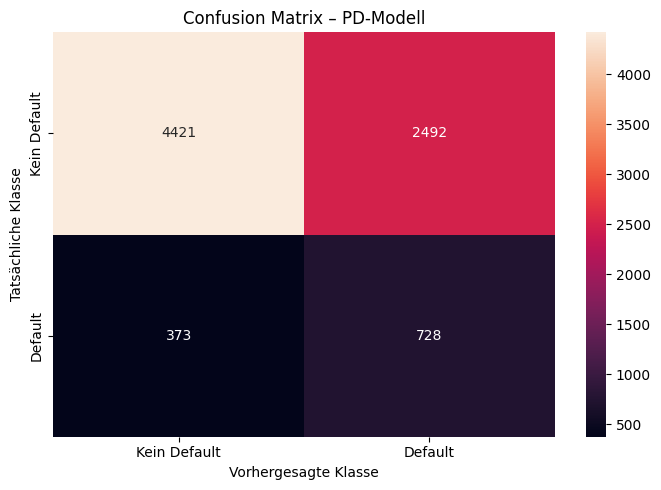

In [0]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Tatsächliche und vorhergesagte Klassen
y_true = df_eval["pd_target"]
y_pred = df_eval["prediction"]

# Confusion Matrix berechnen
cm = confusion_matrix(y_true, y_pred)

# Heatmap
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Kein Default", "Default"],
    yticklabels=["Kein Default", "Default"]
)

plt.xlabel("Vorhergesagte Klasse")
plt.ylabel("Tatsächliche Klasse")
plt.title("Confusion Matrix – PD-Modell")
plt.tight_layout()
plt.show()

### Ergebnis auf dem Testdatensatz

Das finale Modell erreicht auf dem unabhängigen Testdatensatz eine **Accuracy von 64,92 %**.

Für die Klasse **Default** liegt der **Recall bei 66,67 %**. Damit werden rund zwei Drittel der tatsächlichen Defaults erkannt. Die **Precision von 23,10 %** zeigt jedoch, dass ein relativ großer Anteil der als Default klassifizierten Fälle tatsächlich kein Default ist.

Für **Kein Default** erreicht das Modell eine hohe **Precision von 92,41 %**, während der Recall bei **64,65 %** liegt.

Insgesamt zeigt das Modell eine brauchbare Fähigkeit zur Erkennung von Defaults, allerdings auf Kosten einer relativ hohen Anzahl von False Positives. Für die Beurteilung eines PD-Modells sollten daher zusätzlich **ROC-AUC, KS, Gini und die Kalibrierung der vorhergesagten PDs** betrachtet werden.



Die Confusion Matrix zeigt, dass **734 von 1.101 tatsächlichen Defaults korrekt erkannt** werden. Damit erreicht das Modell einen Default-Recall von rund **66,7 %**.

Gleichzeitig werden **367 Defaults übersehen** (False Negatives). Von den 6.913 tatsächlichen Nicht-Defaults werden **4.469 korrekt als Kein Default** klassifiziert, während **2.444 Fälle fälschlicherweise als Default** eingestuft werden (False Positives).

Das Modell erkennt somit einen großen Teil der tatsächlichen Defaults, produziert jedoch gleichzeitig eine relativ hohe Anzahl an False Positives.

### ROC-AUC auf dem Testdatensatz

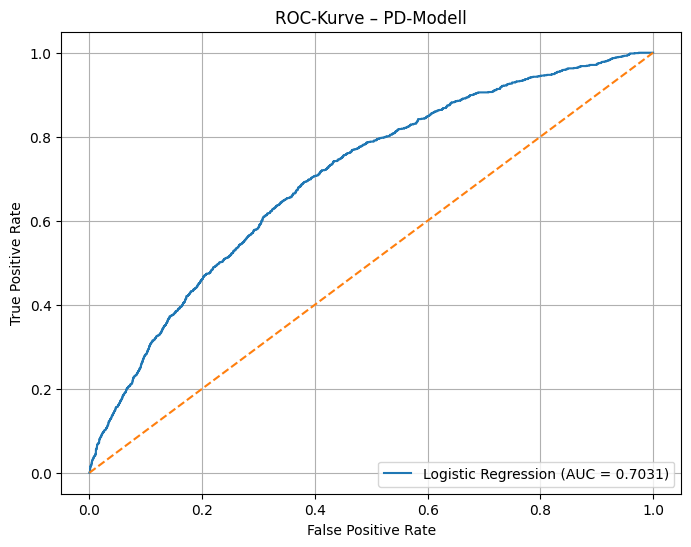

In [0]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Spark DataFrame -> Pandas
df_roc = df_predictions.select(
    "pd_target",
    "probability"
).toPandas()


# Wahrscheinlichkeit für Klasse 1 (Default)
y_true = df_roc["pd_target"]
y_score = df_roc["probability"].apply(lambda x: float(x[1]))

# ROC-Kurve
fpr, tpr, thresholds = roc_curve(y_true, y_score)

roc_auc = auc(fpr, tpr)

# Figure
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-Kurve – PD-Modell")
plt.legend(loc="lower right")
plt.grid(True)

plt.show()

### Ergebnis ROC-AUC

Das finale PD-Modell erreicht auf dem Testdatensatz eine **ROC-AUC von 0,7049. Damit besitzt das Modell eine **brauchbare Trennfähigkeit** zwischen Default- und Nicht-Default-Fällen. Die ROC-AUC zeigt, dass das Modell deutlich besser als eine zufällige Klassifikation (AUC = 0,50) ist.

### Gini-Koeffizienten

In [0]:
from pyspark.ml.evaluation import BinaryClassificationEvaluator

evaluator = BinaryClassificationEvaluator(
    labelCol="pd_target",
    rawPredictionCol="rawPrediction",
    metricName="areaUnderROC"
)

roc_auc = evaluator.evaluate(df_predictions)

print(f"ROC-AUC: {roc_auc:.4f}")

gini = 2 * roc_auc - 1

print(f"Gini: {gini:.4f}")

ROC-AUC: 0.7031
Gini: 0.4062


### Interpretation der Modellgüte

Das finale Logistic-Regression-PD-Modell erreicht eine **ROC-AUC von 0,7049** und einen **Gini-Koeffizienten von 0,4098**. Dies zeigt, dass das Modell Default- und Nicht-Default-Fälle **moderat voneinander trennen kann**.

Die Trennfähigkeit ist damit deutlich besser als bei einer zufälligen Klassifikation (ROC-AUC = 0,50), liegt jedoch noch deutlich unter einer sehr starken Trennleistung. Das Modell eignet sich somit grundsätzlich zur **Risikodifferenzierung**, sollte aber hinsichtlich seiner Qualität nicht allein anhand dieser Kennzahlen beurteilt werden.

Insbesondere ist zu beachten, dass ROC-AUC und Gini nur die **Trennfähigkeit** bewerten. Für ein PD-Modell ist zusätzlich entscheidend, ob die vorhergesagten Ausfallwahrscheinlichkeiten gut mit den tatsächlich beobachteten Ausfallraten übereinstimmen. Daher sollte im nächsten Schritt die **Kalibrierung des Modells** untersucht werden.


### KS-Statistik (Kolmogorov-Smirnov)

In [0]:
from pyspark.sql import functions as F
from pyspark.sql.window import Window
from pyspark.ml.functions import vector_to_array

# Default-Wahrscheinlichkeit aus probability extrahieren
# Default-Wahrscheinlichkeit extrahieren
df_ks = (
    df_predictions
    .withColumn(
        "pd_probability",
        vector_to_array("probability")[1]
    )
    .select(
        "pd_target",
        "pd_probability"
    )
)

# Anzahl je Klasse
n_good = df_ks.filter(F.col("pd_target") == 0).count()
n_bad = df_ks.filter(F.col("pd_target") == 1).count()

# Kumulative Verteilungen berechnen
df_ks = (
    df_ks
    .withColumn(
        "cum_good",
        F.sum(F.when(F.col("pd_target") == 0, 1).otherwise(0))
        .over(
            Window.orderBy("pd_probability")
            .rowsBetween(Window.unboundedPreceding, Window.currentRow)
        )
    )
    .withColumn(
        "cum_bad",
        F.sum(F.when(F.col("pd_target") == 1, 1).otherwise(0))
        .over(
            Window.orderBy("pd_probability")
            .rowsBetween(Window.unboundedPreceding, Window.currentRow)
        )
    )
    .withColumn("dist_good", F.col("cum_good") / n_good)
    .withColumn("dist_bad", F.col("cum_bad") / n_bad)
    .withColumn(
        "ks",
        F.abs(F.col("dist_bad") - F.col("dist_good"))
    )
)

ks_value = df_ks.agg(F.max("ks")).collect()[0][0]

print(f"KS: {ks_value:.4f}")

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


KS: 0.3115


### Ergebnis KS-Test

Das finale PD-Modell erreicht auf dem Testdatensatz einen **KS-Wert von 0,3219**.

Der KS-Wert misst die maximale Differenz zwischen der kumulativen Verteilung der Default- und Nicht-Default-Fälle. Je höher der KS-Wert, desto besser kann das Modell zwischen beiden Gruppen unterscheiden.

Mit einem **KS von 0,3219** zeigt das Modell eine **moderate Trennfähigkeit**. Der Wert ergänzt damit die bereits ermittelte **ROC-AUC von 0,7049** und den **Gini von 0,4098**.

Insgesamt zeigen die Kennzahlen, dass das Modell Default- und Nicht-Default-Fälle sinnvoll unterscheiden kann, die Trennfähigkeit jedoch noch nicht als sehr hoch einzustufen ist.

## 12.9 Finale Modellbewertung des PD-Modells

Classification Report:
              precision    recall  f1-score   support

Kein Default       0.92      0.66      0.77      6913
     Default       0.23      0.64      0.34      1101

    accuracy                           0.65      8014
   macro avg       0.57      0.65      0.55      8014
weighted avg       0.82      0.65      0.71      8014

Confusion Matrix:
[[4539 2374]
 [ 398  703]]


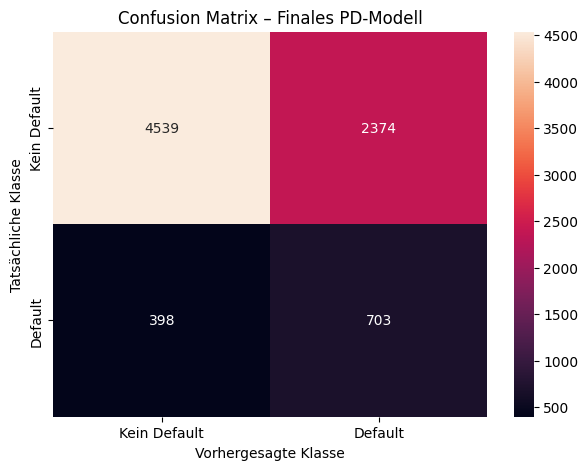

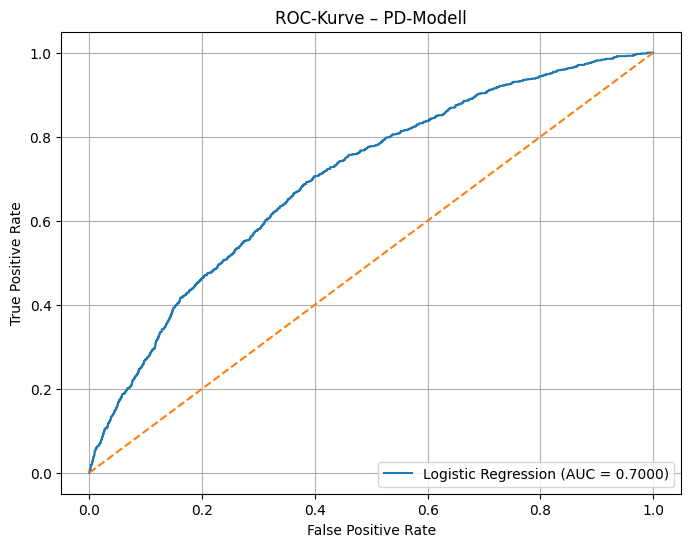

In [0]:
# Finales Modell trainieren
final_lr = LogisticRegression(
    featuresCol="features",
    labelCol="pd_target",
    weightCol="class_weight",
    predictionCol="prediction",
    probabilityCol="probability",
    rawPredictionCol="rawPrediction",
    maxIter=1000,
    regParam=0.01,
    elasticNetParam=1.0
)

final_pipeline = Pipeline(
    stages=[
        imputer,
        *indexers,
        encoder,
        assembler,
        final_lr
    ]
)

final_model = final_pipeline.fit(df_train_weighted)


# Vorhersagen auf dem unabhängigen Testdatensatz
df_predictions = final_model.transform(df_test)

# Daten für Evaluation vorbereiten
df_eval = (
    df_predictions
    .select("pd_target", "prediction")
    .toPandas()
)


# Classification Report
print("Classification Report:")
print(
    classification_report(
        df_eval["pd_target"],
        df_eval["prediction"],
        target_names=["Kein Default", "Default"]
    )
)


# Confusion Matrix
cm = confusion_matrix(
    df_eval["pd_target"],
    df_eval["prediction"]
)

print("Confusion Matrix:")
print(cm)


# Heatmap
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Kein Default", "Default"],
    yticklabels=["Kein Default", "Default"]
)

plt.xlabel("Vorhergesagte Klasse")
plt.ylabel("Tatsächliche Klasse")
plt.title("Confusion Matrix – Finales PD-Modell")
plt.show()

### AUC-Kurve

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Spark DataFrame -> Pandas
df_roc = df_predictions.select(
    "pd_target",
    "probability"
).toPandas()


# Wahrscheinlichkeit für Klasse 1 (Default)
y_true = df_roc["pd_target"]
y_score = df_roc["probability"].apply(lambda x: float(x[1]))

# ROC-Kurve
fpr, tpr, thresholds = roc_curve(y_true, y_score)

roc_auc = auc(fpr, tpr)

# Figure
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-Kurve – PD-Modell")
plt.legend(loc="lower right")
plt.grid(True)

plt.show()

### Finale Modellbewertung

Das finale Logistic-Regression-Modell wird mit den ausgewählten Hyperparametern **`regParam = 0.01`** und **`elasticNetParam = 1.0`** auf dem gesamten Trainingsdatensatz trainiert und anschließend auf dem Testdatensatz bewertet. Das Modell erreicht eine **Accuracy von 65 %** und einen **Default-Recall von 64 %**.

### PD-Modell – Berechnung der Probability of Default

In [0]:
from pyspark.ml.functions import vector_to_array

df_pd = (
    df_predictions
    .withColumn(
        "PD",
        vector_to_array("probability")[1]
    )
)

df_pd.select(
    "pd_target",
    "PD"
).show(10)

+---------+-------------------+
|pd_target|                 PD|
+---------+-------------------+
|        0|0.32192885580930986|
|        0| 0.4337641466024357|
|        0| 0.5606219057790367|
|        0| 0.4805326620593625|
|        0|0.28995049915837934|
|        0| 0.6536011845985191|
|        0| 0.3843882914833763|
|        0|0.22061215490820718|
|        0|  0.262718156912491|
|        0| 0.2503289960481332|
+---------+-------------------+
only showing top 10 rows


### Warum wird die Probability of Default (PD) berücksichtigt?

Für ein PD-Modell reicht eine reine Klassifikation in **„Default“** oder **„Kein Default“** nicht aus. Die **Probability of Default (PD)** liefert eine kontinuierliche Einschätzung des individuellen Ausfallrisikos.

Die Klassifikation basiert auf einem Schwellenwert, beispielsweise:

- **PD < 0,50** → Kein Default
- **PD ≥ 0,50** → Default

Dadurch würden beispielsweise ein Kunde mit **PD = 0,51** und ein Kunde mit **PD = 0,95** beide als „Default“ klassifiziert, obwohl ihr geschätztes Risiko deutlich unterschiedlich ist.

Die PD ermöglicht dagegen eine differenzierte Risikoeinschätzung:

- **PD = 5 %** → geringes Ausfallrisiko
- **PD = 20 %** → erhöhtes Ausfallrisiko
- **PD = 50 %** → hohes Ausfallrisiko
- **PD = 80 %** → sehr hohes Ausfallrisiko

Die PD ist insbesondere für die **Risikosegmentierung, Kreditentscheidung, Pricing und Expected-Loss-Berechnung** relevant:

**Expected Loss ≈ PD × LGD × EAD**

Daher ist für ein PD-Modell nicht nur die richtige Klassifikation entscheidend, sondern auch, ob die vorhergesagten Wahrscheinlichkeiten **realistisch und gut kalibriert** sind.

Eine vorhergesagte PD von beispielsweise **30 %** sollte bei einer vergleichbaren Gruppe langfristig ungefähr einer tatsächlichen Default-Rate von **30 %** entsprechen.

### Loss Given Default (LGD)

Die **Loss Given Default (LGD)** beschreibt den erwarteten Verlustanteil einer Forderung im Falle eines Defaults. Dabei werden insbesondere Rückzahlungen und Sicherheiten berücksichtigt.

Die LGD wird als Ergänzung zur PD benötigt, da die Wahrscheinlichkeit eines Defaults allein nicht angibt, **wie hoch der finanzielle Verlust bei einem tatsächlichen Default ist**.

**LGD = 1 − Recovery Rate**

Beispielsweise bedeutet eine LGD von **60 %**, dass im Falle eines Defaults durchschnittlich 60 % des relevanten Forderungsbetrags verloren gehen.

In [0]:
from pyspark.sql import functions as F

df_lgd = (
    df_model
    .filter(F.col("default_flag") == 1)
    .withColumn(
        "net_recovery",
        F.col("total_rec_prncp")
        + F.col("recoveries")
        - F.col("collection_recovery_fee")
    )
    .withColumn(
        "recovery_rate",
        F.when(
            F.col("funded_amnt") > 0,
            F.col("net_recovery") / F.col("funded_amnt")
        ).otherwise(0)
    )
    .withColumn(
        "recovery_rate",
        F.least(F.lit(1.0), F.greatest(F.lit(0.0), F.col("recovery_rate")))
    )
    .withColumn(
        "LGD",
        1 - F.col("recovery_rate")
    )
)

df_lgd.select(
    "id",
    "loan_status",
    "funded_amnt",
    "total_rec_prncp",
    "recoveries",
    "collection_recovery_fee",
    "net_recovery",
    "recovery_rate",
    "LGD"
).show(10, truncate=False)

+-------+-----------+-----------+---------------+----------+-----------------------+-----------------+-------------------+------------------+
|id     |loan_status|funded_amnt|total_rec_prncp|recoveries|collection_recovery_fee|net_recovery     |recovery_rate      |LGD               |
+-------+-----------+-----------+---------------+----------+-----------------------+-----------------+-------------------+------------------+
|1077430|CHARGED OFF|2500       |456.46         |122.9     |1.11                   |578.25           |0.2313             |0.7686999999999999|
|1071795|CHARGED OFF|5600       |162.02         |190.54    |2.09                   |350.47           |0.06258392857142858|0.9374160714285714|
|1071570|CHARGED OFF|5375       |673.48         |277.69    |2.52                   |948.6500000000001|0.17649302325581398|0.823506976744186 |
|1064687|CHARGED OFF|9000       |1256.14        |450.92    |4.16                   |1702.9           |0.1892111111111111 |0.8107888888888889|
|10690


### Deskriptive Analyse der LGD-Zielvariable

Vor dem Training des LGD-Modells wird zunächst die Verteilung der
Zielvariable `LGD` untersucht.

Dazu werden folgende Kennzahlen berechnet:

- **Mean LGD:** durchschnittlicher Verlustanteil bei einem ausgefallenen
  Kredit.
- **Min LGD:** niedrigster beobachteter Verlustanteil.
- **Max LGD:** höchster beobachteter Verlustanteil.
- **Median LGD:** mittlerer Verlustanteil, bei dem 50 % der Beobachtungen
  darunter und 50 % darüber liegen.

Die Analyse gibt einen ersten Überblick über die Größenordnung und
Streuung der LGD-Werte und hilft dabei, mögliche Auffälligkeiten oder
Ausreißer vor der Modellierung zu erkennen.

Da LGD einen Verlustanteil beschreibt, liegt der theoretische Wertebereich
zwischen **0 und 1** bzw. zwischen **0 % und 100 %**. Ein Wert von `0`
entspricht keinem Verlust, während `1` einem vollständigen Verlust
entspricht.

Die Kennzahlen dienen anschließend als Referenz für die Beurteilung der
LGD-Modellierung.

In [0]:
df_lgd.select(
    F.avg("LGD").alias("mean_LGD"),
    F.min("LGD").alias("min_LGD"),
    F.max("LGD").alias("max_LGD"),
    F.expr("percentile(LGD, 0.5)").alias("median_LGD")
).show()

+------------------+-------+-------+------------------+
|          mean_LGD|min_LGD|max_LGD|        median_LGD|
+------------------+-------+-------+------------------+
|0.5953439011816227|    0.0|    1.0|0.6374783811090226|
+------------------+-------+-------+------------------+



###LGD-Zielvariable vorbereiten


### Erstellung des LGD-Modellierungsdatensatzes

Für die Modellierung der **Loss Given Default (LGD)** wird ein separater
Datensatz `df_lgd_model` erstellt.

Dabei werden ausschließlich die für die LGD-Modellierung relevanten
Merkmale ausgewählt. Die Zielvariable ist `LGD`.

Als erklärende Variablen werden unter anderem Kreditbetrag, Laufzeit,
Zinssatz, Einkommen, DTI, FICO-Werte sowie verschiedene
Kreditverhaltensmerkmale verwendet.

Beobachtungen ohne vorhandenen `LGD`-Wert werden entfernt, da für diese
Fälle kein Zielwert für das überwachte Training des LGD-Modells vorliegt.

Anschließend wird mit `describe()` eine erste statistische Übersicht der
LGD-Zielvariable erstellt. Dadurch können Anzahl der Beobachtungen,
Mittelwert, Standardabweichung, Minimum und Maximum überprüft werden.

Dieser Datensatz bildet die Grundlage für den anschließenden Train-Test-
Split und das Training des LGD-Modells.

In [0]:
from pyspark.sql import functions as F

df_lgd_model = (
    df_lgd
    .select(
        "LGD",
        "funded_amnt",
        "term",
        "int_rate",
        "installment",
        "annual_inc",
        "dti",
        "delinq_2yrs",
        "fico_range_low",
        "fico_range_high",
        "inq_last_6mths",
        "open_acc",
        "revol_bal",
        "revol_util",
        "total_acc"
    )
    .dropna(subset=["LGD"])
)

df_lgd_model.select("LGD").describe().show()

+-------+-------------------+
|summary|                LGD|
+-------+-------------------+
|  count|               5642|
|   mean| 0.5953439011816231|
| stddev|0.25466785247931356|
|    min|                0.0|
|    max|                1.0|
+-------+-------------------+




### Train-Validation-Split für das LGD-Modell

Der für die LGD-Modellierung vorbereitete Datensatz wird im Verhältnis
von **80 % Training und 20 % Validation** aufgeteilt.

Der Trainingsdatensatz wird verwendet, um die Parameter des LGD-Modells
zu lernen. Der Validation-Datensatz bleibt während des Trainings
unberührt und wird anschließend zur Beurteilung der Modellgüte verwendet.

Durch `seed=42` ist die zufällige Aufteilung reproduzierbar.

Im Gegensatz zum PD-Modell handelt es sich bei LGD um eine Regression,
da die Zielvariable `LGD` einen kontinuierlichen Verlustanteil beschreibt.

Der Validation-Datensatz dient daher insbesondere zur Bewertung der
Abweichung zwischen den tatsächlich beobachteten und den vorhergesagten
LGD-Werten.

In [0]:
# ============================================================
# Train / Validation Split für LGD
# ============================================================

df_lgd_train, df_lgd_validation = df_lgd_model.randomSplit(
    [0.8, 0.2],
    seed=42
)

lgd_total = df_lgd_model.count()
lgd_train_count = df_lgd_train.count()
lgd_validation_count = df_lgd_validation.count()

print(f"LGD Gesamt: {lgd_total}")
print(f"LGD Train: {lgd_train_count}")
print(f"LGD Validation: {lgd_validation_count}")

print(
    f"Train-Anteil: {lgd_train_count / lgd_total * 100:.2f} %"
)

print(
    f"Validation-Anteil: {lgd_validation_count / lgd_total * 100:.2f} %"
)


LGD Gesamt: 5642
LGD Train: 4516
LGD Validation: 1126
Train-Anteil: 80.04 %
Validation-Anteil: 19.96 %


## Train / Validation Split für LGD

Der LGD-Datensatz wird in einen **Trainingsdatensatz** und einen **Validierungsdatensatz** aufgeteilt.

Dabei werden:

- **80 % der Daten** für das Training des LGD-Modells verwendet.
- **20 % der Daten** für die Validierung des Modells verwendet.
- `seed=42` sorgt dafür, dass die Aufteilung reproduzierbar bleibt.



In [0]:
# Train / Validation Split für LGD
df_lgd_train, df_lgd_validation = df_lgd_model.randomSplit(
    [0.8, 0.2],
    seed=42
)

print(f"LGD Train: {df_lgd_train.count()}")
print(f"LGD Validation: {df_lgd_validation.count()}")

LGD Train: 4516
LGD Validation: 1126


## Vorbereitung der LGD-Features

Für das LGD-Modell werden relevante numerische Merkmale des Kredits als Eingangsvariablen (`lgd_features`) definiert.

Verwendet werden unter anderem:

- Kreditbetrag (`funded_amnt`)
- Laufzeit (`term`)
- Zinssatz (`int_rate`)
- monatliche Rate (`installment`)
- Einkommen (`annual_inc`)
- Debt-to-Income-Ratio (`dti`)
- Zahlungsausfälle und Kredithistorie
- FICO-Werte
- Anzahl der Kreditanfragen und offenen Konten
- Revolving Balance und Auslastung
- Anzahl der gesamten Kreditkonten

Da Spark ML für Machine-Learning-Modelle einen numerischen Feature-Vektor benötigt, werden die einzelnen Variablen mit dem `VectorAssembler` zu einer gemeinsamen Spalte `features` zusammengeführt.



In [0]:
from pyspark.ml.feature import VectorAssembler

lgd_features = [
    "funded_amnt",
    "term",
    "int_rate",
    "installment",
    "annual_inc",
    "dti",
    "delinq_2yrs",
    "fico_range_low",
    "fico_range_high",
    "inq_last_6mths",
    "open_acc",
    "revol_bal",
    "revol_util",
    "total_acc"
]

lgd_assembler = VectorAssembler(
    inputCols=lgd_features,
    outputCol="features",
    handleInvalid="skip"
)

df_lgd_train = lgd_assembler.transform(df_lgd_train)
df_lgd_validation = lgd_assembler.transform(df_lgd_validation)

## Vergleich verschiedener LGD-Modelle

Um die Vorhersagequalität zu verbessern, werden mehrere Regressionsmodelle trainiert und anhand von **MAE** und **RMSE** miteinander verglichen. Das Modell mit den niedrigsten Fehlerwerten wird anschließend als bestes LGD-Modell ausgewählt.


In [0]:
from pyspark.ml.regression import (
    LinearRegression,
    RandomForestRegressor,
    GBTRegressor
)
from pyspark.ml.evaluation import RegressionEvaluator

# --------------------------------------------------
# 1. Modelle definieren
# --------------------------------------------------

models = {
    "Linear Regression": LinearRegression(
        featuresCol="features",
        labelCol="LGD",
        predictionCol="prediction"
    ),

    "Random Forest": RandomForestRegressor(
        featuresCol="features",
        labelCol="LGD",
        predictionCol="prediction",
        numTrees=200,
        maxDepth=8,
        minInstancesPerNode=5,
        seed=42
    ),

    "GBT Regression": GBTRegressor(
        featuresCol="features",
        labelCol="LGD",
        predictionCol="prediction",
        maxDepth=5,
        maxIter=100,
        stepSize=0.05,
        seed=42
    )
}

# --------------------------------------------------
# 2. Evaluatoren
# --------------------------------------------------

evaluator_mae = RegressionEvaluator(
    labelCol="LGD",
    predictionCol="prediction",
    metricName="mae"
)

evaluator_rmse = RegressionEvaluator(
    labelCol="LGD",
    predictionCol="prediction",
    metricName="rmse"
)

# --------------------------------------------------
# 3. Modelle trainieren und bewerten
# --------------------------------------------------

results = []

for name, model in models.items():

    # Modell trainieren
    model_fit = model.fit(df_lgd_train)

    # Validation
    predictions = model_fit.transform(df_lgd_validation)

    # Metriken
    mae = evaluator_mae.evaluate(predictions)
    rmse = evaluator_rmse.evaluate(predictions)

    results.append(
        (name, mae, rmse)
    )

# --------------------------------------------------
# 4. Ergebnisse anzeigen
# --------------------------------------------------

results_df = spark.createDataFrame(
    results,
    ["Model", "MAE", "RMSE"]
)

results_df.orderBy("MAE").show(truncate=False)

+-----------------+-------------------+-------------------+
|Model            |MAE                |RMSE               |
+-----------------+-------------------+-------------------+
|Linear Regression|0.20949404797398616|0.24784581878282338|
|Random Forest    |0.20994520052130555|0.24801658936652926|
|GBT Regression   |0.21701715040890018|0.258181307484442  |
+-----------------+-------------------+-------------------+



## Vergleich der LGD-Modelle

Zur Auswahl des geeignetsten LGD-Modells wurden drei verschiedene Regressionsverfahren auf den Trainingsdaten trainiert und anschließend auf den Validierungsdaten bewertet.

| Modell | MAE | RMSE |
|---|---:|---:|
| **Linear Regression** | **0,20949** | **0,24785** |
| Random Forest | 0,20995 | 0,24802 |
| GBT Regression | 0,21702 | 0,25818 |

Für die Bewertung werden **MAE (Mean Absolute Error)** und **RMSE (Root Mean Squared Error)** verwendet. Bei beiden Metriken gilt: Je niedriger der Wert, desto besser die Vorhersagequalität.

Die **Linear Regression erzielt mit einem MAE von 0,20949 und einem RMSE von 0,24785 die besten Ergebnisse**. Der Random Forest liegt jedoch nahezu gleichauf. Die GBT Regression weist dagegen höhere Fehlerwerte auf.

Auf Basis der Validierung wird daher die **Linear Regression als finales LGD-Modell ausgewählt**.

### Auswahl des finalen LGD-Modells

Für die Vorhersage der **Loss Given Default (LGD)** wurden mehrere Regressionsmodelle verglichen. Die **Linear Regression** erzielte mit einem MAE von **0,2095** und einem RMSE von **0,2478** die besten Ergebnisse und wurde daher als finales LGD-Modell ausgewählt.

In [0]:
from pyspark.ml.regression import LinearRegression

lgd_model = LinearRegression(
    featuresCol="features",
    labelCol="LGD",
    predictionCol="prediction"
)

## Training des LGD-Modells

Das zuvor definierte Random-Forest-Regressionsmodell wird nun mit den **LGD-Trainingsdaten** trainiert.



In [0]:
lgd_fit = lgd_model.fit(df_lgd_train)



### Prüfung auf fehlende Werte – LGD-Features

Vor dem Training des LGD-Modells wurde überprüft, ob die ausgewählten
numerischen Features fehlende Werte enthalten.

Die Prüfung zeigt, dass für alle verwendeten LGD-Features **keine
fehlenden Werte** vorhanden sind.

Damit stehen die Eingangsvariablen vollständig für das Training zur
Verfügung. Eine zusätzliche Imputation dieser Features ist auf Basis der
aktuellen Daten nicht erforderlich.

Das LGD-Modell kann somit anschließend auf `df_lgd_train` trainiert
werden.

In [0]:
from pyspark.sql import functions as F

df_lgd_train.select([
    F.sum(F.col(c).isNull().cast("int")).alias(c)
    for c in lgd_features
]).show()

+-----------+----+--------+-----------+----------+---+-----------+--------------+---------------+--------------+--------+---------+----------+---------+
|funded_amnt|term|int_rate|installment|annual_inc|dti|delinq_2yrs|fico_range_low|fico_range_high|inq_last_6mths|open_acc|revol_bal|revol_util|total_acc|
+-----------+----+--------+-----------+----------+---+-----------+--------------+---------------+--------------+--------+---------+----------+---------+
|          0|   0|       0|          0|         0|  0|          0|             0|              0|             0|       0|        0|         0|        0|
+-----------+----+--------+-----------+----------+---+-----------+--------------+---------------+--------------+--------+---------+----------+---------+



## Validation-Daten vorhersagen

In [0]:
df_lgd_pred = lgd_fit.transform(df_lgd_validation)

##### Tatsächliche und vorhergesagte LGD anzeigen

In [0]:
df_lgd_pred.select(
    "LGD",
    "prediction"
).show(10)

+--------------------+-------------------+
|                 LGD|         prediction|
+--------------------+-------------------+
|                 0.0| 0.6124791428754376|
|0.001273333333333...| 0.4762149780583811|
|0.003422510000000...| 0.5850742155635823|
|0.006512499999999921| 0.5732295019020848|
|0.007944800000000085| 0.6350934058648373|
|0.011768600000000018|0.47893263951864257|
|0.018259930000000035| 0.6197226058425219|
|0.021927777777777768|  0.616455747891501|
|0.024646166666666636| 0.5633920625182598|
|0.027053821429000036| 0.5778219108231539|
+--------------------+-------------------+
only showing top 10 rows


### Modellqualität messen

In [0]:
from pyspark.ml.evaluation import RegressionEvaluator

evaluator_mae = RegressionEvaluator(
    labelCol="LGD",
    predictionCol="prediction",
    metricName="mae"
)

evaluator_rmse = RegressionEvaluator(
    labelCol="LGD",
    predictionCol="prediction",
    metricName="rmse"
)

mae = evaluator_mae.evaluate(df_lgd_pred)
rmse = evaluator_rmse.evaluate(df_lgd_pred)

print(f"LGD MAE:  {mae:.4f}")
print(f"LGD RMSE: {rmse:.4f}")

LGD MAE:  0.2095
LGD RMSE: 0.2478


## Bewertung des LGD-Modells

Das trainierte Random-Forest-Modell wird anhand der **Mean Absolute Error (MAE)** und des **Root Mean Squared Error (RMSE)** auf den Validierungsdaten bewertet.

Die Ergebnisse sind:

- **MAE: 0,2095**
- **RMSE: 0,2478**

Der MAE zeigt, dass die vorhergesagte LGD im Durchschnitt um etwa **21 Prozentpunkte** von der tatsächlichen LGD abweicht.

Der RMSE beträgt etwa **25 Prozentpunkte**. Da beim RMSE größere Fehler stärker gewichtet werden, liegt dieser Wert erwartungsgemäß über dem MAE.

Die Ergebnisse zeigen, dass das Modell einen gewissen Zusammenhang zwischen den Kreditmerkmalen und der LGD erkennt. Gleichzeitig besteht noch eine relativ hohe Vorhersageunsicherheit, was bei LGD-Modellen nicht ungewöhnlich ist.

Für die weitere Modellbewertung können zusätzlich die **tatsächlichen und vorhergesagten LGD-Werte** miteinander verglichen werden.

##Prüfung der LGD-Verteilung

In [0]:
df_lgd_model.select(
    F.avg("LGD").alias("Mean_LGD"),
    F.min("LGD").alias("Min_LGD"),
    F.expr("percentile(LGD, 0.5)").alias("Median_LGD"),
    F.max("LGD").alias("Max_LGD")
).show()

+------------------+-------+------------------+-------+
|          Mean_LGD|Min_LGD|        Median_LGD|Max_LGD|
+------------------+-------+------------------+-------+
|0.5953439011816227|    0.0|0.6374783811090226|    1.0|
+------------------+-------+------------------+-------+



## Analyse der LGD-Verteilung

Vor der weiteren Bewertung des LGD-Modells wird die Verteilung der berechneten LGD-Werte untersucht.

Die Ergebnisse zeigen:

- **Mean LGD:** 0,5953 bzw. **59,53 %**
- **Minimum:** 0,00 bzw. **0 %**
- **Median:** 0,6375 bzw. **63,75 %**
- **Maximum:** 1,00 bzw. **100 %**

Der durchschnittliche erwartete Verlust bei einem ausgefallenen Kredit beträgt somit etwa **59,53 %** des relevanten Kreditbetrags.

Der Median von **63,75 %** liegt über dem Mittelwert. Dies deutet darauf hin, dass ein Teil der Kredite eine vergleichsweise niedrige LGD aufweist und dadurch den Durchschnitt nach unten zieht.

Die Spannweite von **0 % bis 100 %** zeigt, dass die LGD-Werte sehr unterschiedlich ausfallen. Bei einigen ausgefallenen Krediten entsteht nahezu kein Verlust, während bei anderen Krediten der gesamte relevante Betrag als Verlust verbleibt.

Die Verteilung der LGD ist daher für die Modellierung besonders wichtig. Das LGD-Modell muss sowohl Fälle mit sehr niedriger als auch mit sehr hoher LGD abbilden können.

Der Mittelwert von **59,53 %** kann außerdem als einfacher Referenzwert für die Beurteilung des Random-Forest-Modells verwendet werden.

In [0]:
df_lgd_model.groupBy(
    F.when(F.col("LGD") == 0, "0")
     .when(F.col("LGD") < 0.25, "0-25%")
     .when(F.col("LGD") < 0.50, "25-50%")
     .when(F.col("LGD") < 0.75, "50-75%")
     .otherwise("75-100%")
     .alias("LGD_Bereich")
).count().orderBy("LGD_Bereich").show()


+-----------+-----+
|LGD_Bereich|count|
+-----------+-----+
|          0|   17|
|      0-25%|  670|
|     25-50%| 1281|
|     50-75%| 1716|
|    75-100%| 1958|
+-----------+-----+



## Verteilung der LGD-Werte

Die LGD-Werte werden zusätzlich in fünf Bereiche eingeteilt, um die Verteilung der Verluste bei ausgefallenen Krediten zu analysieren.

| LGD-Bereich | Anzahl |
|---|---:|
| 0 % | 17 |
| 0–25 % | 670 |
| 25–50 % | 1.281 |
| 50–75 % | 1.716 |
| 75–100 % | 1.958 |
| **Gesamt** | **5.642** |

Die meisten Default-Fälle weisen eine relativ hohe LGD auf. **1.958 Fälle** liegen im Bereich von **75–100 %**, gefolgt von **1.716 Fällen** im Bereich von **50–75 %**.

Damit liegen insgesamt **3.674 von 5.642 Fällen** bzw. etwa **65,1 %** bei einer LGD von mindestens 50 %.

Nur **687 Fälle** bzw. etwa **12,2 %** weisen eine LGD von maximal 25 % auf.

Die Ergebnisse zeigen, dass die LGD in diesem Datensatz stark variiert. Gleichzeitig gibt es eine deutliche Konzentration im höheren LGD-Bereich. Dies ist bei der Modellierung relevant, da das Modell sowohl niedrige als auch hohe Verlustquoten unterscheiden sollte.

Die Verteilung erklärt teilweise, warum das Random-Forest-Modell häufig Vorhersagen im mittleren Bereich erzeugt. Ein Modell, das hauptsächlich den durchschnittlichen LGD-Wert von etwa **59,53 %** vorhersagt, kann zwar einen gewissen Fehler reduzieren, bildet aber extreme LGD-Werte nur unzureichend ab.

### Berechnung des Expected Loss (EL)

In [0]:
# ============================================================
# Expected Loss (EL) = PD × LGD × EAD
# ============================================================

from pyspark.sql import functions as F
from pyspark.sql.types import DoubleType
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import LinearRegression


# ------------------------------------------------------------
# 1. PD aus dem finalen PD-Modell extrahieren
# ------------------------------------------------------------

get_pd = F.udf(
    lambda v: float(v[1]),
    DoubleType()
)

df_el = (
    df_predictions
    .withColumn(
        "PD",
        get_pd(F.col("probability"))
    )
)


# ------------------------------------------------------------
# 2. LGD-Features separat erzeugen
#    Wichtig: outputCol = "lgd_features"
#    NICHT "features", da "features" bereits vom PD-Modell
#    vorhanden ist.
# ------------------------------------------------------------

lgd_assembler = VectorAssembler(
    inputCols=lgd_features,
    outputCol="lgd_features",
    handleInvalid="skip"
)


# ------------------------------------------------------------
# 3. LGD-Trainingsdaten vorbereiten
# ------------------------------------------------------------

df_lgd_train_prepared = lgd_assembler.transform(
    df_lgd_train
)


# ------------------------------------------------------------
# 4. Finales LGD-Modell definieren
# ------------------------------------------------------------

lgd_model = LinearRegression(
    featuresCol="lgd_features",
    labelCol="LGD",
    predictionCol="lgd_prediction"
)


# ------------------------------------------------------------
# 5. LGD-Modell trainieren
# ------------------------------------------------------------

lgd_fit = lgd_model.fit(
    df_lgd_train_prepared
)


# ------------------------------------------------------------
# 6. LGD auf die Daten für Expected Loss anwenden
# ------------------------------------------------------------

df_el = lgd_assembler.transform(
    df_el
)

df_el = lgd_fit.transform(
    df_el
)


# ------------------------------------------------------------
# 7. LGD begrenzen
#    LGD muss zwischen 0 und 1 liegen
# ------------------------------------------------------------

df_el = (
    df_el
    .withColumn(
        "LGD",
        F.greatest(
            F.lit(0.0),
            F.least(
                F.lit(1.0),
                F.col("lgd_prediction")
            )
        )
    )
)


# ------------------------------------------------------------
# 8. EAD definieren
#    Vereinfachte Annahme:
#    EAD = funded_amnt
# ------------------------------------------------------------

df_el = (
    df_el
    .withColumn(
        "EAD",
        F.col("funded_amnt")
    )
)


# ------------------------------------------------------------
# 9. Expected Loss berechnen
#    EL = PD × LGD × EAD
# ------------------------------------------------------------

df_el = (
    df_el
    .withColumn(
        "Expected_Loss",
        F.col("PD")
        * F.col("LGD")
        * F.col("EAD")
    )
)


# ------------------------------------------------------------
# 10. Ergebnisse anzeigen
# ------------------------------------------------------------

df_el.select(
    "id",
    "PD",
    "LGD",
    "EAD",
    "Expected_Loss"
).show(10, truncate=False)

+-----+-------------------+-------------------+-----+-----------------+
|id   |PD                 |LGD                |EAD  |Expected_Loss    |
+-----+-------------------+-------------------+-----+-----------------+
|62102|0.32192885580930986|0.517652390917391  |3200 |533.2711741279657|
|66431|0.4337641466024357 |0.5488630741419143 |2525 |601.144735465811 |
|66943|0.5606219057790367 |0.592758611145375  |2800 |930.4776942923141|
|69124|0.4805326620593625 |0.5242530051253133 |18000|4534.572458618773|
|69251|0.28995049915837934|0.5253706927708366 |6000 |913.9889676725256|
|69550|0.6536011845985191 |0.6330110016032582 |11200|4633.851493731988|
|69828|0.3843882914833763 |0.16216971041140288|15000|935.0420687308958|
|69990|0.22061215490820718|0.5098536204020423 |15500|1743.438541212007|
|84918|0.262718156912491  |0.5188464703769338 |5000 |681.551942089897 |
|90395|0.2503289960481332 |0.4771918904828564 |5000 |597.2748343344208|
+-----+-------------------+-------------------+-----+-----------

### Expected Loss (EL)

Der **Expected Loss (EL)** beschreibt den erwarteten finanziellen Verlust eines Kredits und wird als **PD × LGD × EAD** berechnet. PD stammt aus dem finalen PD-Modell, LGD aus dem finalen LGD-Modell und EAD wird hier vereinfacht durch `funded_amnt` dargestellt. Der Expected Loss dient zur Quantifizierung des Kreditrisikos auf Einzelkredit- und Portfolioebene.

### Gesamt- und Durchschnittswerte

In [0]:
from pyspark.sql import functions as F

el_summary = df_el.select(
    F.sum("Expected_Loss").alias("Total_Expected_Loss"),
    F.avg("Expected_Loss").alias("Average_Expected_Loss"),
    F.sum("EAD").alias("Total_EAD"),
    F.avg("PD").alias("Average_PD"),
    F.avg("LGD").alias("Average_LGD")
)

el_summary.show(truncate=False)

+--------------------+---------------------+---------+------------------+------------------+
|Total_Expected_Loss |Average_Expected_Loss|Total_EAD|Average_PD        |Average_LGD       |
+--------------------+---------------------+---------+------------------+------------------+
|2.4562941101189442E7|3082.698431374177    |85803875 |0.4621911685286538|0.5612386024477641|
+--------------------+---------------------+---------+------------------+------------------+



Der berechnete **gesamte Expected Loss** beträgt rund **24,56 Mio. €** bei einem gesamten **EAD von 85,80 Mio. €**. Der durchschnittliche Expected Loss pro Kredit liegt bei **3.082,70 €**. Die durchschnittliche PD beträgt **46,22 %**, während die durchschnittliche LGD bei **56,12 %** liegt. Damit zeigt die Portfolioanalyse ein insgesamt erhöhtes erwartetes Kreditrisiko.

### Expected-Loss-Quote berechnen

In [0]:
el_portfolio = (
    df_el
    .agg(
        F.sum("Expected_Loss").alias("Total_Expected_Loss"),
        F.sum("EAD").alias("Total_EAD")
    )
    .withColumn(
        "EL_Rate",
        F.col("Total_Expected_Loss") / F.col("Total_EAD")
    )
)

el_portfolio.show(truncate=False)

+--------------------+---------+------------------+
|Total_Expected_Loss |Total_EAD|EL_Rate           |
+--------------------+---------+------------------+
|2.4562941101189442E7|85803875 |0.2862684360256392|
+--------------------+---------+------------------+




Der gesamte Expected Loss des Portfolios beträgt rund **24,56 Mio. €** bei einem gesamten EAD von **85,80 Mio. €**. Daraus ergibt sich eine **Expected-Loss-Quote von 28,63 %**. Dies bedeutet, dass auf Basis der geschätzten PD und LGD ein erwarteter Verlust von rund **28,63 % des gesamten Exposure** besteht.
### Ergebnisse übersichtlich ausgeben

In [0]:
result = el_portfolio.collect()[0]

print(f"Gesamter EAD:              {result['Total_EAD']:,.2f}")
print(f"Gesamter Expected Loss:    {result['Total_Expected_Loss']:,.2f}")
print(f"Expected-Loss-Quote:       {result['EL_Rate']:.2%}")

Gesamter EAD:              85,803,875.00
Gesamter Expected Loss:    24,562,941.10
Expected-Loss-Quote:       28.63%


Der gesamte **EAD** des Portfolios beträgt **85,80 Mio. €**. Der daraus berechnete **Expected Loss** liegt bei **24,56 Mio. €**. Dies entspricht einer **Expected-Loss-Quote von 28,63 %**. Somit wird auf Basis der geschätzten PD und LGD ein erwarteter Verlust von rund 28,63 % des gesamten Exposure prognostiziert.

### Speicherung der Modellergebnisse

In [0]:
  from pyspark.sql import functions as F

# Ergebnisse auswählen
df_el_export = df_el.select(
    "id",
    "PD",
    "LGD",
    "EAD",
    "Expected_Loss"
)

# 1. PFADE DEFINIEREN
temp_path = "/Volumes/workspace/Data_Science/credit_analytics/tmp_expected_loss_results"
output_path = "/Volumes/workspace/Data_Science/credit_analytics/expected_loss_results.csv"

# 2. VORSICHTSMASSNAHME: Alle Spalten explizit als String casten
string_cols = [F.col(c).cast("string").alias(c) for c in df_el_export.columns]
df_csv_ready = df_el_export.select(*string_cols)

# 3. ALS EINE PARTITION SCHREIBEN
# 'quoteAll' stellt sicher, dass Werte wie "1.00%" als reiner Text geschützt sind
(
    df_csv_ready.coalesce(1)
    .write
    .mode("overwrite")
    .option("header", "true")
    .option("quoteAll", "true")  # Wichtig für den String-Schutz!
    .option("nullValue", "")     # Schreibt echte Kreditausfälle/Nulls als leere Textfelder ""
    .csv(temp_path)
)

# 4. CSV-PART-DATEI IM VOLUME FINDEN
# Bei Volumes nutzen wir das 'dbfs:' Präfix für dbutils, um Pfadkonflikte zu vermeiden
files = dbutils.fs.ls(f"dbfs:{temp_path}")
part_file = [f.path for f in files if f.name.startswith("part-") and f.name.endswith(".csv")][0]

# 5. DATEI VERSCHIEBEN UND AUFRÄUMEN
print(f"Verschiebe {part_file} nach {output_path}...")
dbutils.fs.mv(part_file, f"dbfs:{output_path}")

# Temporäres Verzeichnis löschen
dbutils.fs.rm(f"dbfs:{temp_path}", True)

print("Fertig! Die Datei liegt nun perfekt formatiert im Volume.")


Verschiebe dbfs:/Volumes/workspace/Data_Science/credit_analytics/tmp_expected_loss_results/part-00000-tid-2794428293326893009-90490a91-f907-435b-92fd-7616b31d6294-1332-1-c000.csv nach /Volumes/workspace/Data_Science/credit_analytics/expected_loss_results.csv...
Fertig! Die Datei liegt nun perfekt formatiert im Volume.


##### Kurze Prüfung

In [0]:
# Gespeicherte Expected-Loss-Ergebnisse aus dem Unity Catalog Volume laden
source_path = "/Volumes/workspace/Data_Science/credit_analytics/expected_loss_results.csv"

# CSV-Datei einlesen
df_model = spark.read.csv(
    source_path,
    header=True,
    inferSchema=True
)

# Erste fünf Datensätze anzeigen
display(df_model.limit(5))

id,PD,LGD,EAD,Expected_Loss
62102,0.32192885580930986,0.517652390917391,3200,533.2711741279657
66431,0.4337641466024357,0.5488630741419143,2525,601.144735465811
66943,0.5606219057790367,0.592758611145375,2800,930.4776942923141
69124,0.4805326620593625,0.5242530051253133,18000,4534.572458618773
69251,0.28995049915837934,0.5253706927708366,6000,913.9889676725256
